# Danish 1.3 "blitz" versus Danish 1.2 corner wavefront sensor output, a full night (v2)

**Author:** Aaron Roodman  
**Date Created:** 2026-09-22  
**Last Modified:** 2026-09-22  
**Status:** Complete  
**Keywords:** AOS, CWFS, corner wavefront sensor, blitz, Danish, donut, Zernike, unpaired, paired, format review  

## Description

Comparison of the corner-wavefront-sensor (CWFS) wavefront Zernikes for **every in-focus
(`acq`) member of the Full Array Mode (FAM) triplets on `day_obs = 20260315`**: Josh Meyers'
new Danish 1.3 "blitz" **unpaired** reduction against the Danish 1.2 **paired** reduction
currently used in this repository. It is the corner-sensor counterpart of the FAM comparison
in `blitz_vs_danish12_20260315.ipynb`, and follows that notebook's structure so the two can
be read side by side.

The notebook has two halves. Sections 5 to 9 are a **single-visit deep dive** on the
reference visit `2026031500123` — the column census, the table metadata and provenance, the
Noll basis, and the structure of the donut match. Those are properties of the *format*, not
of a visit, so they are established once. Section 10 then runs the same match and the same
comparison over **all 62 comparable visits** of the night and does the statistics on the
pooled sample, which is what makes the per-Noll numbers meaningful.

Key functionality:
1. Discover the comparable visits by intersecting the two collections' registry queries for
   the night: 74 visits carry `donutBlitzResults` and 62 carry
   `aggregateAOSVisitTableRaw`, with **62 in both and 12 blitz-only**.
2. On the reference visit, build a column census, read the blitz table metadata (which
   requires `parameters={'strip_astropy_meta_yaml': False}`, a parameter that **raises** on
   the Danish 1.2 dataset), roll up the Butler input provenance, and assert the Noll basis
   from both products' own metadata.
3. Establish the donut match. The corner geometry makes this structurally different from
   FAM: the two halves of each corner raft, `SW0` (extra-focal) and `SW1` (intra-focal), are
   **different CCDs looking at different stars**, so the blitz `donut_id` sets on the two
   sides are completely disjoint. Danish 1.2 pairs a star on `SW0` with a *different* star on
   `SW1`, and the pairing is recoverable only from the detector id embedded in its
   `intra_donut_id` / `extra_donut_id` strings — its `detector` column labels both members of
   a pair by the extra-focal half. The match is therefore on detector id plus pixel position,
   one side at a time, with the per-visit centroid offset measured and removed.
4. Loop that match over all 62 visits and compare the deviation and intrinsic Zernikes in
   micrometres of wavefront in the Optical Coordinate System (OCS) three ways against the
   single Danish 1.2 joint fit: the blitz intra-focal (`SW1`) half alone, the extra-focal
   (`SW0`) half alone, and the **mean of the two**.

**Main results.** All 62 visits read and matched with **no failures**, yielding **1215
pooled Danish 1.2 pairs** from 2095 `used` rows — 12 to 25 pairs per visit, median 20.

The **intrinsic** wavefront is an exact convention test and it passes on the whole night:
the mean of the two blitz halves reproduces the Danish 1.2 per-pair intrinsic to a median
**1.33e-06 µm of wavefront** and a maximum **4.17e-03 µm of wavefront** over all 1215 pairs
and 21 Noll terms, against a median |intrinsic| of **0.0105 µm of wavefront**. Either half
alone differs by a median **1.19e-03 µm of wavefront**, the field-position gradient across
the separation between the two donuts of a pair. So Danish 1.2's per-pair intrinsic is the
arithmetic mean of the two donuts' own field-position evaluations, and the units, the Noll
indexing and the OCS frame match exactly with no scaling and no rotation.

For the **fitted deviation** the pooled sample **withdraws the conclusion the reference
visit alone suggested**, which is the main reason this extension was worth doing. The
intra-focal (`SW1`) half alone is clearly the **worst** of the three estimators on every
metric — median Pearson r **0.6680** and nMAD of the difference **0.0524 µm of wavefront**
over the 21 fitted Noll terms, against **0.8755** and **0.0206 µm of wavefront** for the
extra-focal (`SW0`) half and **0.8696** and **0.0276 µm of wavefront** for the mean of the
two. But the extra half and the mean of both are **not** cleanly ordered: the mean has the
higher pooled Pearson r on 12 of the 21 terms and the higher per-visit median r (0.8319
against 0.7977, n = 62 visits), while the extra half has the smaller nMAD on 14 of 21 terms.
That split is structured by Noll order — the extra half wins the low-order terms Z4 to Z11
(nMAD 0.0702 against 0.0754 µm of wavefront) and the mean wins the higher-order terms Z12 to
Z26 (0.0133 against 0.0146 µm of wavefront) — and because the low-order terms carry the
larger scatter they dominate the median over all 21. So at n = 1215 **neither the mean of
both halves nor the extra half alone is uniformly better**; the single visit's apparently
clean "the mean beats both halves" (n = 15 pairs) does not survive. The `SW1`-versus-`SW0`
asymmetry is itself the finding, and it is **not explained** here.

**Output:** Tables and plots inline; no files written.

**Based on:** `blitz_vs_danish12_20260315.ipynb`, the FAM counterpart, whose helper functions
and plot idioms are reused here; `aos/docs/ts_wep_zernike_intrinsics.md` for the meaning of
`zk`, `zk_intrinsic` and `zk_deviation`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-22 | Aaron Roodman | Initial version: corner-sensor comparison of the Danish 1.3 blitz unpaired reduction against Danish 1.2 paired, on the in-focus member of the 20260315 triplet |
| 2026-09-22 | Aaron Roodman | Extended from the single reference visit to all 62 comparable in-focus visits of `day_obs = 20260315`, pooling 1215 Danish 1.2 pairs. The pooled sample withdraws the single-visit finding that the mean of the two corner halves beats either half alone: the intra-focal SW1 half is clearly worst, but the mean and the extra-focal SW0 half are not cleanly ordered and which wins depends on the metric and the Noll order. Added the per-visit distributions of the centroid offset, the match yield and the per-visit Pearson r |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access and the Visit List](#data)
5. [Column Census and Table Metadata](#census)
6. [Noll Basis and Selection Accounting](#noll)
7. [Matching Donuts](#match)
8. [Zernike Comparison, Reference Visit](#zernike)
    - [8.1 Mean of the two unpaired sides](#zernike-mean)
9. [Donut Width and Signal-to-Noise Comparison](#blur)
10. [All Visits of the Night](#allvisits)
    - [10.1 Pooled three-way Zernike comparison](#pooled)
    - [10.2 Variation across visits](#pervisit)
11. [Findings for Josh](#findings)

<a id='params'></a>
## 1. Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

BUTLER_REPO = '/repo/main'

# The 20260315 FAM triplet. The corner wavefront sensors (CWFS) are read out on the
# IN-FOCUS (acq) member, seq_num 123, because the corner sensors are permanently
# defocused by +/- 1.5 mm either side of the science focal plane: SW0 sits extra-focal
# and SW1 intra-focal, so one in-focus science exposure already yields both sides.
DAY_OBS = 20260315
SEQ_INTRA = 121                       # intra-focal FAM member, img_type cwfs
SEQ_EXTRA = 122                       # extra-focal FAM member = the FAM key
SEQ_ACQ = 123                         # in-focus member, img_type acq -- the one used here
VISIT_ACQ = DAY_OBS * 100000 + SEQ_ACQ         # 2026031500123

# The reference visit for the single-visit deep dive in sections 5 to 9. Those sections
# describe the FORMAT -- the columns, the metadata, the Noll basis, the structure of the
# match -- so they are established once on one visit rather than repeated 62 times.
# Section 10 then loops the match and the comparison over every comparable visit.
REFERENCE_VISIT = VISIT_ACQ

# Set to an integer to run section 10 on only the first that many visits while
# iterating; None uses every comparable visit of the night.
MAX_VISITS = None

# Danish 1.2 paired, the corner-triplet collection. Note this is the fam_cwfs_triplet
# collection, NOT the fam/ collection used by the FAM notebook.
COLL_OLD = ('LSSTCam/runs/aos/fam_cwfs_triplet/danish_1_2_0_alpha0/wep_17_6_1/'
            'dv_4_5_0/bin_x2/refitWcs')
DATASET_OLD = 'aggregateAOSVisitTableRaw'

# Danish 1.3 blitz corner, unpaired (Josh Meyers, ts_wep tag blitz-prototype-v2).
COLL_BLITZ = 'u/jmeyers3/t614_corner_unpaired'
DATASET_BLITZ = 'donutBlitzResults'

# Zernike conventions. The blitz zk_deviation_* vector has length 27 and is 0-INDEXED
# (column j is Noll j); the Danish 1.2 table carries only the 21 fitted Noll listed in
# its meta['nollIndices']. NOLL is the map from Danish 1.2 column order to blitz column
# index, asserted against BOTH products' metadata in section 6.
NOLL = list(range(4, 20)) + list(range(22, 27))       # 21 fitted Noll indices
COORD_BLITZ = 'ocs'                   # blitz column suffix, lower case
COORD_OLD = 'OCS'                     # Danish 1.2 column suffix, upper case

# Corner half-sensor to side of focus. SW0 is extra-focal (defocal offset +1.5 mm) and
# SW1 intra-focal (-1.5 mm); this is asserted from the blitz defocal_offsets in
# section 7 rather than assumed.
HALF_SIDE = {'SW0': 'extra', 'SW1': 'intra'}

# Per-CCD donut match tolerance, in detector pixels. Larger than the FAM notebook's
# 5.0 pixels because the corner donuts are sparse (5 to 11 blitz rows per half-sensor),
# so an accidental neighbour within the tolerance is far less likely here.
TOL_PIX = 6.0

print(f'FAM triplet on day_obs = {DAY_OBS}: intra seq_num = {SEQ_INTRA}, '
      f'extra seq_num = {SEQ_EXTRA}, in-focus seq_num = {SEQ_ACQ}')
print(f'corner wavefront sensors are read on the in-focus visit id = {VISIT_ACQ}')
print(f'reference visit for the sections 5 to 9 deep dive = {REFERENCE_VISIT}')
print(f'section 10 runs over every comparable visit of the night, '
      f'MAX_VISITS = {MAX_VISITS}')
print(f'{len(NOLL)} fitted Noll indices assumed, asserted in section 6: {NOLL}')

FAM triplet on day_obs = 20260315: intra seq_num = 121, extra seq_num = 122, in-focus seq_num = 123
corner wavefront sensors are read on the in-focus visit id = 2026031500123
reference visit for the sections 5 to 9 deep dive = 2026031500123
section 10 runs over every comparable visit of the night, MAX_VISITS = None
21 fitted Noll indices assumed, asserted in section 6: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]


<a id='setup'></a>
## 2. Setup & Imports

In [2]:
import sys
import textwrap
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr

from lsst.daf.butler import Butler

# Notebook path bootstrap: walk up to the topic directory (the one holding code/),
# which works at any depth under aos/notebooks/.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))                 # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))               # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):        # code/<study>/ subdirs
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common.utils import setup_plotting, nmad
from lsst.ts.intrinsic.wavefront.common.zernike_names import NOLL_NAMES

setup_plotting()
print(f'topic directory = {_TOPIC}')

topic directory = /sdf/home/r/roodman/notebooks/rubin-work/aos


<a id='functions'></a>
## 3. Helper Functions

`column_census`, `zk_label`, `corr_pair` and `deduplicate` are taken unchanged from the
FAM notebook `blitz_vs_danish12_20260315.ipynb`, so the two notebooks report the same
quantities computed the same way. `focus_side` is likewise unchanged — it finds the
varying `defocal_offsets` element rather than assuming one, which matters because the
corner product varies **element 0** while the FAM product varies element 1.
`match_one_side` is the FAM version adapted to match on the blitz **`det_id`** rather than
on a detector name, which is required here: the Danish 1.2 `detector` column names the
extra-focal half of the pair for both members, so it cannot supply the intra-focal
detector.

In [3]:
def column_census(tables):
    """Per-column dtype and array shape across several tables, as one frame.

    Parameters
    ----------
    tables : `dict`
        Maps a short source label to an object exposing ``colnames`` (an
        `astropy.table.Table`) or ``columns`` (a `pandas.DataFrame`).

    Returns
    -------
    census : `pandas.DataFrame`
        One row per column name seen in any table, one column per source. Each
        cell is ``'dtype'`` for a scalar column, ``'dtype(n,)'`` for an array
        column, or the empty string when the source lacks that column.
    """
    def _cols(t):
        return list(t.colnames) if hasattr(t, 'colnames') else list(t.columns)

    def _describe(t, c):
        a = np.asarray(t[c])
        if a.ndim == 1 and a.dtype == object and len(a) and isinstance(a[0], np.ndarray):
            # pandas stores a fixed-length array column as object-of-ndarray
            return f'{a[0].dtype}{np.shape(a[0])}'
        if a.ndim > 1:
            return f'{a.dtype}{a.shape[1:]}'
        return str(a.dtype)

    all_cols, seen = [], set()
    for t in tables.values():
        for c in _cols(t):
            if c not in seen:
                seen.add(c)
                all_cols.append(c)
    rows = {}
    for label, t in tables.items():
        cols = set(_cols(t))
        rows[label] = [_describe(t, c) if c in cols else '' for c in all_cols]
    return pd.DataFrame(rows, index=pd.Index(all_cols, name='column'))


def focus_side(table):
    """Label each row of a blitz table by its side of focus.

    The blitz ``defocal_offsets`` column is a 3-vector of defocal offsets in
    metres. Which element carries the offset is **not** the same in the two blitz
    products -- the FAM table varies element 1 and the corner table element 0 --
    so the varying element is found rather than assumed.

    Parameters
    ----------
    table : `astropy.table.Table`
        Blitz table carrying ``defocal_offsets``.

    Returns
    -------
    side : `numpy.ndarray`
        String array of ``'intra'`` (negative offset, in metres) or ``'extra'``
        (positive).
    element : `int`
        Index of the ``defocal_offsets`` element that varies.
    """
    off = np.asarray(table['defocal_offsets'], dtype=float)
    varying = [k for k in range(off.shape[1]) if len(np.unique(off[:, k])) > 1]
    if len(varying) != 1:
        raise ValueError(f'expected exactly one varying defocal_offsets element, '
                         f'found {varying}')
    k = varying[0]
    return np.where(off[:, k] < 0, 'intra', 'extra'), k


def parse_det_id(donut_ids):
    """Detector id out of a Danish 1.2 ``donut_id`` string.

    The Danish 1.2 corner ``intra_donut_id`` / ``extra_donut_id`` have the form
    ``f'{visit_id}_{det_id:03d}_{seq:03d}'``, e.g. ``'2026031500123_192_001'``.
    The detector id is the only place the **intra-focal** half-sensor of a pair is
    recorded: the table's ``detector`` column names the extra-focal half for both
    members of the pair.

    Parameters
    ----------
    donut_ids : `array_like` of `str`
        Danish 1.2 donut identifier strings.

    Returns
    -------
    det_id : `numpy.ndarray`
        Integer detector ids, one per input string.
    """
    return np.array([int(str(s).split('_')[1]) for s in np.asarray(donut_ids, dtype=str)])


def match_one_side(blitz, old_det_id, old_x, old_y, blitz_rows, *, tol_pix, shift=None):
    """Match blitz rows to Danish 1.2 rows per CCD on detector pixel position.

    The corner version of the FAM notebook's matcher. It matches on the integer
    ``det_id`` rather than a detector name, because the Danish 1.2 ``detector``
    column cannot supply the intra-focal half-sensor of a pair.

    The two products' centroid conventions differ by a constant offset of a few
    pixels, so the match is done in two passes: a first pass measures the median
    nearest-neighbour offset, and the second pass matches with that offset removed.

    Parameters
    ----------
    blitz : `astropy.table.Table`
        The full quality-selected blitz table, carrying ``det_id``, ``x_det`` and
        ``y_det`` in **unbinned detector pixels**.
    old_det_id : `numpy.ndarray`
        Danish 1.2 detector id for the side being matched, one per Danish 1.2 row,
        as returned by `parse_det_id`.
    old_x, old_y : `numpy.ndarray`
        Danish 1.2 centroid for the side being matched, in detector pixels.
    blitz_rows : `numpy.ndarray`
        Integer indices into `blitz` of the rows on the side of focus being
        matched.
    tol_pix : `float`
        Maximum separation for a match, in detector pixels, applied after the
        offset is removed.
    shift : `tuple` of `float`, optional
        ``(dx, dy)`` offset in detector pixels to subtract from the blitz
        positions. Measured from the data when omitted.

    Returns
    -------
    idx_old : `numpy.ndarray`
        Integer indices into the Danish 1.2 rows.
    idx_blitz : `numpy.ndarray`
        Integer indices into `blitz`, parallel to `idx_old`.
    sep_pix : `numpy.ndarray`
        Separation of each matched pair after the offset is removed, in pixels.
    shift : `tuple` of `float`
        The offset actually used, in detector pixels.
    """
    det_b = np.asarray(blitz['det_id'], dtype=int)
    xb = np.asarray(blitz['x_det'], dtype=float)
    yb = np.asarray(blitz['y_det'], dtype=float)
    dets = np.unique(det_b[blitz_rows])

    if shift is None:
        # First pass: unconstrained nearest neighbour, to measure the offset.
        dxs, dys = [], []
        for det in dets:
            oi = np.where(old_det_id == det)[0]
            bi = blitz_rows[det_b[blitz_rows] == det]
            if len(oi) == 0 or len(bi) == 0:
                continue
            tree = cKDTree(np.column_stack([old_x[oi], old_y[oi]]))
            _, k = tree.query(np.column_stack([xb[bi], yb[bi]]))
            dxs.append(xb[bi] - old_x[oi][k])
            dys.append(yb[bi] - old_y[oi][k])
        shift = (float(np.median(np.concatenate(dxs))),
                 float(np.median(np.concatenate(dys))))

    io_all, ib_all, sep_all = [], [], []
    for det in dets:
        oi = np.where(old_det_id == det)[0]
        bi = blitz_rows[det_b[blitz_rows] == det]
        if len(oi) == 0 or len(bi) == 0:
            continue
        tree = cKDTree(np.column_stack([old_x[oi], old_y[oi]]))
        dist, k = tree.query(np.column_stack([xb[bi] - shift[0], yb[bi] - shift[1]]),
                             distance_upper_bound=tol_pix)
        good = np.isfinite(dist) & (dist < tol_pix)
        io_all.append(oi[k[good]])
        ib_all.append(bi[good])
        sep_all.append(dist[good])
    if not io_all:
        z = np.empty(0, dtype=int)
        return z, z, np.empty(0, dtype=float), shift
    return (np.concatenate(io_all), np.concatenate(ib_all),
            np.concatenate(sep_all), shift)


def deduplicate(idx_old, idx_blitz, sep_pix):
    """Keep only the nearest blitz match for each Danish 1.2 row.

    Parameters
    ----------
    idx_old, idx_blitz : `numpy.ndarray`
        Parallel match index arrays.
    sep_pix : `numpy.ndarray`
        Match separation in detector pixels, used to pick the winner.

    Returns
    -------
    keep : `numpy.ndarray`
        Boolean mask over the input pairs.
    """
    keep = np.zeros(len(idx_old), dtype=bool)
    best = {}
    for i in np.argsort(sep_pix, kind='stable'):
        key = int(idx_old[i])
        if key not in best:
            best[key] = i
            keep[i] = True
    return keep


def zk_label(j):
    """``'Z4 Defocus'``-style label for Noll index `j`."""
    return f'Z{j} {NOLL_NAMES.get(j, "")}'.strip()


def corr_pair(x, y):
    """Pearson r, Spearman rho and n over the finite entries of `x` and `y`.

    Returns
    -------
    r : `float`
        Pearson correlation coefficient (dimensionless), NaN if n < 3.
    rho : `float`
        Spearman rank correlation coefficient (dimensionless), NaN if n < 3.
    n : `int`
        Number of finite pairs used.
    """
    g = np.isfinite(x) & np.isfinite(y)
    n = int(g.sum())
    if n < 3:
        return np.nan, np.nan, n
    return float(pearsonr(x[g], y[g])[0]), float(spearmanr(x[g], y[g])[0]), n


def split_meta(meta):
    """Separate a blitz table's meta into its three parts.

    Parameters
    ----------
    meta : `dict`
        The ``.meta`` of a blitz table read with ``strip_astropy_meta_yaml=False``.

    Returns
    -------
    science : `list` [`str`]
        Science and configuration keys, excluding ``det_meta``.
    provenance : `list` [`str`]
        ``LSST.BUTLER.*`` keys, which carry the input dataset provenance.
    det_meta : `dict`
        Per detector-exposure diagnostics, keyed ``f'{det_name}_{visit_id}'``.
    """
    science = [k for k in meta
               if k != 'det_meta' and not k.startswith('LSST.BUTLER')]
    provenance = [k for k in meta if k.startswith('LSST.BUTLER')]
    return science, provenance, meta.get('det_meta', {})


def input_provenance(meta):
    """Roll up the ``LSST.BUTLER.INPUT.*`` keys by dataset type.

    Parameters
    ----------
    meta : `dict`
        The ``.meta`` of a blitz table read with ``strip_astropy_meta_yaml=False``.

    Returns
    -------
    rollup : `dict` [`str`, `tuple`]
        Dataset type -> (count, sorted list of RUN collection names).
    """
    n = int(meta['LSST.BUTLER.N_INPUTS'])
    counts = Counter()
    runs = defaultdict(set)
    for i in range(n):
        dtype = meta.get(f'LSST.BUTLER.INPUT.{i}.DATASETTYPE')
        counts[dtype] += 1
        runs[dtype].add(meta.get(f'LSST.BUTLER.INPUT.{i}.RUN'))
    return {k: (counts[k], sorted(runs[k])) for k in counts}

<a id='data'></a>
## 4. Data Access and the Visit List

First the visit list for the whole night, discovered by intersecting the two collections'
registry queries rather than hardcoded, then the two products for the reference visit.

The two reads are **not symmetric**, and the asymmetry is itself a format finding: the blitz
table needs `parameters={'strip_astropy_meta_yaml': False}` or its `.meta` comes back empty,
while passing that same parameter to the Danish 1.2 dataset raises a `KeyError`, because the
parameter belongs to the blitz formatter and the `AstropyTable` storage class behind
`aggregateAOSVisitTableRaw` does not know it.

In [4]:
butler = Butler(BUTLER_REPO)
KEEP_META = {'strip_astropy_meta_yaml': False}


def visits_on_night(dataset_type, collection, day_obs):
    """Visit ids of one dataset type in one collection on one night.

    Parameters
    ----------
    dataset_type : `str`
        Butler dataset type name.
    collection : `str`
        Collection to search, ``findFirst=True``.
    day_obs : `int`
        Observing night in the ``YYYYMMDD`` form. A visit id is
        ``day_obs * 100000 + seq_num``, so the night is recovered by integer
        division.

    Returns
    -------
    visits : `list` [`int`]
        Sorted visit ids present for that dataset type on that night.
    """
    refs = butler.registry.queryDatasets(dataset_type, collections=collection,
                                         findFirst=True)
    return sorted({r.dataId['visit'] for r in refs
                   if r.dataId['visit'] // 100000 == day_obs})


visits_blitz = visits_on_night(DATASET_BLITZ, COLL_BLITZ, DAY_OBS)
visits_old = visits_on_night(DATASET_OLD, COLL_OLD, DAY_OBS)
visits_both = sorted(set(visits_blitz) & set(visits_old))
blitz_only = sorted(set(visits_blitz) - set(visits_old))
old_only = sorted(set(visits_old) - set(visits_blitz))

print(f'day_obs = {DAY_OBS}, in-focus visits carrying each product:')
print(f'  {DATASET_BLITZ:28s} in {COLL_BLITZ}: {len(visits_blitz)} visits')
print(f'  {DATASET_OLD:28s} in the Danish 1.2 collection : {len(visits_old)} visits')
print(f'  comparable (in BOTH)        : {len(visits_both)} visits')
print(f'  blitz only (no Danish 1.2 counterpart): {len(blitz_only)} visits, '
      f'seq_num {[v % 100000 for v in blitz_only]}')
print(f'  Danish 1.2 only                       : {len(old_only)} visits')
assert len(visits_both) == 62, f'expected 62 comparable visits, found {len(visits_both)}'
assert REFERENCE_VISIT in visits_both, 'the reference visit is not comparable'
print('\nasserted: 62 comparable visits, and the reference visit is one of them')

print(f'\ncomparable seq_num: {[v % 100000 for v in visits_both]}')
_d = np.diff([v % 100000 for v in visits_both])
print(f'consecutive seq_num differences: {sorted(set(_d.tolist()))} -- the stride of 3 is '
      'the FAM')
print('triplet spacing (intra, extra, in-focus), and the larger gaps separate FAM blocks.')

VISITS = visits_both if MAX_VISITS is None else visits_both[:MAX_VISITS]
print(f'\nsection 10 will process {len(VISITS)} visits (MAX_VISITS = {MAX_VISITS})')

day_obs = 20260315, in-focus visits carrying each product:
  donutBlitzResults            in u/jmeyers3/t614_corner_unpaired: 74 visits
  aggregateAOSVisitTableRaw    in the Danish 1.2 collection : 62 visits
  comparable (in BOTH)        : 62 visits
  blitz only (no Danish 1.2 counterpart): 12 visits, seq_num [74, 77, 80, 83, 86, 89, 92, 95, 98, 101, 104, 107]
  Danish 1.2 only                       : 0 visits

asserted: 62 comparable visits, and the reference visit is one of them

comparable seq_num: [123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 185, 188, 191, 194, 197, 200, 203, 206, 209, 212, 215, 218, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 277, 280, 283, 286, 289, 292, 295, 298, 301, 304, 307, 310, 323, 326, 329, 332, 335, 338, 341, 344, 347, 350, 353, 356]
consecutive seq_num differences: [3, 13, 23] -- the stride of 3 is the FAM
triplet spacing (intra, extra, in-focus), and the larger gaps separate FAM blocks.

section 10 will process

In [5]:
# --- Danish 1.3 blitz corner, unpaired, on the REFERENCE visit ---
blitz = butler.get(DATASET_BLITZ, collections=COLL_BLITZ, instrument='LSSTCam',
                   visit=REFERENCE_VISIT, parameters=KEEP_META)
print(f'Danish 1.3 blitz corner : {len(blitz):4d} rows, {len(blitz.colnames)} columns, '
      f'{len(blitz.meta)} metadata keys  (visit {REFERENCE_VISIT})')

# The default read hides the metadata entirely -- recorded here so the notebook shows
# why the parameter is required rather than merely using it.
_stripped = butler.get(DATASET_BLITZ, collections=COLL_BLITZ, instrument='LSSTCam',
                       visit=REFERENCE_VISIT)
print(f'  the same dataset read WITHOUT strip_astropy_meta_yaml=False: '
      f'{len(_stripped.meta)} metadata keys')

# --- Danish 1.2 paired corner ---
old = butler.get(DATASET_OLD, collections=COLL_OLD, instrument='LSSTCam',
                 visit=REFERENCE_VISIT)
print(f'Danish 1.2 paired corner: {len(old):4d} rows, {len(old.colnames)} columns, '
      f'{len(old.meta)} metadata keys  (visit {REFERENCE_VISIT})')

# And the parameter that the blitz read REQUIRES is rejected outright here.
try:
    butler.get(DATASET_OLD, collections=COLL_OLD, instrument='LSSTCam',
               visit=REFERENCE_VISIT, parameters=KEEP_META)
except Exception as exc:
    print(f'  the same parameter on the Danish 1.2 dataset raises '
          f'{type(exc).__name__}: {exc}')

Danish 1.3 blitz corner :   68 rows, 61 columns, 359 metadata keys  (visit 2026031500123)
  the same dataset read WITHOUT strip_astropy_meta_yaml=False: 0 metadata keys


Danish 1.2 paired corner:   26 rows, 48 columns, 12 metadata keys  (visit 2026031500123)
  the same parameter on the Danish 1.2 dataset raises KeyError: "Parameter 'strip_astropy_meta_yaml' not understood by StorageClass AstropyTable"


In [6]:
# Selection flags on each side, before anything else is done with the tables.
fit_ok = np.asarray(blitz['group_fit_success'], dtype=bool)
used_old = np.asarray(old['used'], dtype=bool)
print(f'blitz group_fit_success True : {int(fit_ok.sum()):3d} of {len(blitz)} rows')
print(f'Danish 1.2 used == True      : {int(used_old.sum()):3d} of {len(old)} rows')
print()
print('SAMPLE SIZE. This is the binding limitation of the whole notebook: the Danish 1.2')
print(f'corner table holds {len(old)} rows on this visit, {int(used_old.sum())} of them '
      'used. Every statistic below')
print('is quoted with its n, and none of them should be read as a precision measurement.')

blitz group_fit_success True :  58 of 68 rows
Danish 1.2 used == True      :  21 of 26 rows

SAMPLE SIZE. This is the binding limitation of the whole notebook: the Danish 1.2
corner table holds 26 rows on this visit, 21 of them used. Every statistic below
is quoted with its n, and none of them should be read as a precision measurement.


<a id='census'></a>
## 5. Column Census and Table Metadata

Every column of both products side by side, with dtype and array shape. A blank cell means
that source does not carry the column.

The two schemas are essentially disjoint by name, and the shapes differ in a structural
way: the Danish 1.2 corner table carries one row per **pair** with per-side `*_intra` /
`*_extra` copies of the position columns, while the blitz carries one row per **donut on one
CCD**, with no pairing at all.

In [7]:
census = column_census({'blitz_corner': blitz, 'old_paired': old})
print(f'{len(census)} distinct column names across the two corner tables')
with pd.option_context('display.max_rows', 250, 'display.width', 250):
    display(census)

blitz_cols = set(blitz.colnames)
old_cols = set(old.colnames)
print(f'\nblitz columns: {len(blitz_cols)}   Danish 1.2 columns: {len(old_cols)}'
      f'   shared by name: {len(blitz_cols & old_cols)}')
print(f'shared column names: {sorted(blitz_cols & old_cols)}')
print('\nblitz-only columns (new in Danish 1.3):')
print(textwrap.fill(', '.join(sorted(blitz_cols - old_cols)), 96,
                    initial_indent='    ', subsequent_indent='    '))
print('\nDanish 1.2-only columns (absent from the blitz corner product):')
print(textwrap.fill(', '.join(sorted(old_cols - blitz_cols)), 96,
                    initial_indent='    ', subsequent_indent='    '))

106 distinct column names across the two corner tables


,blitz_corner,old_paired
column,,
visit_id,int64,
det_id,int64,
det_name,<U7,
donut_id,int64,
band,<U1,
candidate,bool,
x_det,float64,
y_det,float64,
thx_ccs,float64,



blitz columns: 61   Danish 1.2 columns: 48   shared by name: 3
shared column names: ['coord_dec', 'coord_ra', 'snr']

blitz-only columns (new in Danish 1.3):
    astrom_mag, band, bkg, bkg_std, blend_frac, candidate, defocal_offsets, det_id, det_name,
    donut_id, donut_radius, fit_dx, fit_dy, fit_flux, flux, group_fit_cost, group_fit_elapsed,
    group_fit_nfev, group_fit_njev, group_fit_optimality, group_fit_outcome, group_fit_success,
    group_fwhm, group_id, group_setup_elapsed, group_size, inner_frac, model_img,
    n_nearby_astrom, n_nearby_photo, nearby_astrom_dx_det, nearby_astrom_dy_det,
    nearby_astrom_mag, nearby_photo_dx_det, nearby_photo_dy_det, nearby_photo_mag, outer_frac,
    outer_sector_minmax_frac, photo_mag, rejected_inner_frac, rejected_outer_frac, rejected_sat,
    rejected_snr, stamp, thx_ccs, thx_ocs, thy_ccs, thy_ocs, visit_id, wf_img, x_det, y_det,
    zk_deviation_ccs, zk_deviation_eb, zk_deviation_ocs, zk_intrinsic_ccs, zk_intrinsic_eb,
    zk_intrinsic

In [8]:
# Table metadata. The blitz meta splits into three very different parts; the Danish 1.2
# meta is a flat dict of 12 keys with no provenance block at all.
sci, prov, det_meta = split_meta(blitz.meta)
print(f'blitz corner meta: {len(blitz.meta)} keys = {len(sci)} science/config + '
      f'{len(prov)} LSST.BUTLER provenance + det_meta ({len(det_meta)} '
      f'detector-exposure entries)')
print(f'Danish 1.2 meta  : {len(old.meta)} keys, no provenance block')

print('\nBlitz science/config metadata:')
for k in sci:
    if k == 'notes':
        continue
    print(f'  {k:24s} = {blitz.meta[k]}')

print('\nDanish 1.2 metadata:')
for k, v in old.meta.items():
    if k == 'estimatorInfo':
        keys = sorted(v) if hasattr(v, 'keys') else type(v).__name__
        print(f'  {k:18s} -> per-donut diagnostics, keys = {keys}')
    elif k == 'nollIndices':
        print(f'  {k:18s} = {[int(j) for j in v]}')
    else:
        print(f'  {k:18s} = {v}')

print(f'\nPer-detector-exposure det_meta, {len(det_meta)} entries; keys on one entry:')
_k0 = sorted(det_meta)[0]
print(f'  {_k0!r} -> {sorted(det_meta[_k0])}')

blitz corner meta: 359 keys = 39 science/config + 319 LSST.BUTLER provenance + det_meta (8 detector-exposure entries)
Danish 1.2 meta  : 12 keys, no provenance block

Blitz science/config metadata:
  ref_visit_id             = 2026031500123
  intra_visit_id           = 2026031500123
  extra_visit_id           = 2026031500123
  exposure_group           = 2026-03-16T02:04:25.104
  mode                     = corner
  run_elapsed              = 6.3976663909852505 s
  refcat_elapsed           = 1.0312091186642647 s
  butler_elapsed           = 6.660779228433967 s
  butler_times             = {'crosstalk': <Quantity 0.19990939 s>, 'flat': <Quantity 1.98317081 s>, 'intrinsicZernikes': <Quantity 0.47918095 s>, 'linearizer': <Quantity 0.99830297 s>, 'ptc': <Quantity 0.9362277 s>, 'raws': <Quantity 2.06310234 s>, 'refCat': <Quantity 0.00088507 s>}
  cutout_elapsed           = 2.1270041316747665 s
  danish_elapsed           = 3.085176534950733 s
  photo_filter_name        = phot_g_mean
  astrom_f

In [9]:
# The angle metadata, as a units cross-check. The blitz stores astropy Quantity in deg;
# the Danish 1.2 meta stores BARE FLOATS IN RADIANS with no unit attached, which is the
# same asymmetry the FAM notebook found. Converting shows they are the same numbers.
print('Camera rotator and boresight angles. The frame matters: the rotator angle is what '
      'relates')
print('the camera-fixed CCS to the telescope-fixed OCS, so a unit error here would rotate '
      'every')
print('Zernike comparison in section 8.')
for key_b, key_o in (('rot_tel_pos', 'rotTelPos'),
                     ('boresight_rot_angle', 'rotAngle'),
                     ('boresight_par_angle', 'parallacticAngle')):
    qb = blitz.meta[key_b]
    vo_rad = float(old.meta[key_o])
    vo_deg = np.degrees(vo_rad)
    print(f'  blitz {key_b:20s} = {qb.to_value("deg"):12.8f} deg   |   '
          f'Danish 1.2 {key_o:16s} = {vo_rad:.8f} rad = {vo_deg:12.8f} deg   |   '
          f'difference = {abs(qb.to_value("deg") - vo_deg):.2e} deg')

print(f'\nblitz binning = {blitz.meta["binning"]} (dimensionless, pixels per bin per '
      f'axis); stamp_frame = {blitz.meta["stamp_frame"]!r}; '
      f'stamp_size = {blitz.meta["stamp_size"]} pixels')
print(f'the Danish 1.2 collection is bin_x2 as well, from its name: {COLL_OLD}')
print(f'\nblitz mode = {blitz.meta["mode"]!r}, wf_mode = {blitz.meta["wf_mode"]!r}, '
      f'ref_visit_id = {blitz.meta["ref_visit_id"]}, '
      f'intra_visit_id = {blitz.meta["intra_visit_id"]}, '
      f'extra_visit_id = {blitz.meta["extra_visit_id"]}')

Camera rotator and boresight angles. The frame matters: the rotator angle is what relates
the camera-fixed CCS to the telescope-fixed OCS, so a unit error here would rotate every
Zernike comparison in section 8.
  blitz rot_tel_pos          =   0.17689282 deg   |   Danish 1.2 rotTelPos        = 0.00308736 rad =   0.17689282 deg   |   difference = 2.54e-13 deg
  blitz boresight_rot_angle  =  11.24886774 deg   |   Danish 1.2 rotAngle         = 0.19632978 rad =  11.24886774 deg   |   difference = 1.07e-14 deg
  blitz boresight_par_angle  = 101.42576056 deg   |   Danish 1.2 parallacticAngle = 1.77021347 rad = 101.42576056 deg   |   difference = 2.42e-13 deg

blitz binning = 2 (dimensionless, pixels per bin per axis); stamp_frame = 'CCS'; stamp_size = 167 pixels
the Danish 1.2 collection is bin_x2 as well, from its name: LSSTCam/runs/aos/fam_cwfs_triplet/danish_1_2_0_alpha0/wep_17_6_1/dv_4_5_0/bin_x2/refitWcs

blitz mode = 'corner', wf_mode = 'unpaired', ref_visit_id = 2026031500123, intra_

In [10]:
# Input provenance, rolled up by dataset type: which calibration each product used.
roll = input_provenance(blitz.meta)
print(f'blitz corner: N_INPUTS = {int(blitz.meta["LSST.BUTLER.N_INPUTS"])} input '
      f'datasets, {len(roll)} dataset types')
print(f'  output RUN: {blitz.meta["LSST.BUTLER.RUN"]}')
for dtype, (k, rlist) in sorted(roll.items(), key=lambda kv: -kv[1][0]):
    print(f'    {dtype:22s} n = {k:4d} detector-exposures')
    for r in rlist:
        print(f'        {r}')
print('\nThe Danish 1.2 table carries no provenance block, so the calibrations behind '
      'it cannot')
print('be recovered from the table itself -- only from the collection name.')

blitz corner: N_INPUTS = 104 input datasets, 7 dataset types
  output RUN: u/jmeyers3/t614_corner_unpaired/20260911T222216Z
    the_monster_20250219   n =   56 detector-exposures
        refcats/DM-49042/the_monster_20250219
    raw                    n =    8 detector-exposures
        LSSTCam/raw/all
    ptc                    n =    8 detector-exposures
        LSSTCam/calib/DM-53722/3s_v2/ptcGen.20260120a/20260122T004851Z
    flat                   n =    8 detector-exposures
        LSSTCam/calib/DM-53722/3s_v2/flatAnaglyphGen-i.20260120a/20260123T180410Z
    linearizer             n =    8 detector-exposures
        LSSTCam/calib/DM-53722/3s_v2/linearizerGen.20260120a/20260121T010101Z
    crosstalk              n =    8 detector-exposures
        LSSTCam/calib/DM-51599/cbp_crosstalk/crosstalkGen.20251121a/20251121T223910Z
    intrinsicZernikes      n =    8 detector-exposures
        LSSTCam/calib/DM-55048/intrinsicZernikes.v1.0/intrinsicsGen.20260528a

The Danish 1.2 table carri

<a id='noll'></a>
## 6. Noll Basis and Selection Accounting

Both products state their fitted Noll set in their own metadata, so unlike the first pass of
the FAM notebook nothing has to be inferred here — but the encoding of the *not*-fitted
entries inside the blitz array still differs between the two unused ranges, and the
comparison in section 8 depends on the indexing being right, so both are asserted.

In [11]:
dev_b = np.asarray(blitz[f'zk_deviation_{COORD_BLITZ}'], dtype=float)
int_b = np.asarray(blitz[f'zk_intrinsic_{COORD_BLITZ}'], dtype=float)
noll_old = [int(j) for j in old.meta['nollIndices']]
noll_blitz = [int(j) for j in blitz.meta['noll_indices']]

print(f'blitz zk_deviation_{COORD_BLITZ} shape = {dev_b.shape}   '
      f'zk_intrinsic_{COORD_BLITZ} shape = {int_b.shape}')
print(f'Danish 1.2 zk_deviation_{COORD_OLD} shape = '
      f'{np.asarray(old[f"zk_deviation_{COORD_OLD}"], dtype=float).shape}')
print(f'\nblitz meta noll_indices    ({len(noll_blitz)} entries) = {noll_blitz}')
print(f'Danish 1.2 meta nollIndices ({len(noll_old)} entries) = {noll_old}')
print(f'NOLL assumed in the Parameters cell         = {NOLL}')
assert noll_blitz == NOLL, f'blitz noll_indices {noll_blitz} != NOLL {NOLL}'
assert noll_old == NOLL, f'Danish 1.2 nollIndices {noll_old} != NOLL {NOLL}'
print('Both products agree with NOLL, so blitz[:, NOLL] lines up column for column with '
      'the')
print('Danish 1.2 vector. Asserted, not assumed.')

# The blitz vector is 0-indexed: column j is Noll j. Indices 0-3 are not fitted
# (identically zero) and 20, 21 are all-NaN -- exactly the two the Noll set omits
# between 19 and 22. The two encodings for "not fitted" are different, which is worth
# knowing when writing a reader.
zero_idx = [j for j in range(dev_b.shape[1])
            if np.isfinite(dev_b[:, j]).any()
            and np.allclose(dev_b[:, j][np.isfinite(dev_b[:, j])], 0.0)]
nan_idx = [j for j in range(dev_b.shape[1]) if np.isfinite(dev_b[:, j]).sum() == 0]
print(f'\nblitz deviation columns identically zero : {zero_idx}')
print(f'blitz deviation columns entirely NaN      : {nan_idx}')
assert zero_idx == [0, 1, 2, 3], f'unexpected zero columns: {zero_idx}'
assert nan_idx == [20, 21], f'unexpected all-NaN columns: {nan_idx}'
print(f'blitz intrinsic finite through Noll index '
      f'{max(j for j in range(int_b.shape[1]) if np.isfinite(int_b[:, j]).any())} '
      f'(vector length {int_b.shape[1]})')

blitz zk_deviation_ocs shape = (68, 27)   zk_intrinsic_ocs shape = (68, 67)
Danish 1.2 zk_deviation_OCS shape = (26, 21)

blitz meta noll_indices    (21 entries) = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
Danish 1.2 meta nollIndices (21 entries) = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
NOLL assumed in the Parameters cell         = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
Both products agree with NOLL, so blitz[:, NOLL] lines up column for column with the
Danish 1.2 vector. Asserted, not assumed.

blitz deviation columns identically zero : [0, 1, 2, 3]
blitz deviation columns entirely NaN      : [20, 21]
blitz intrinsic finite through Noll index 66 (vector length 67)


In [12]:
# Row accounting on each side.
dev_finite = np.isfinite(dev_b[:, NOLL]).all(axis=1)
print(f'blitz group_fit_success True        : {int(fit_ok.sum()):3d} rows')
print(f'blitz finite on the 21 fitted Noll : {int(dev_finite.sum()):3d} rows')
print(f'  disagreement (either direction)  : {int((fit_ok != dev_finite).sum()):3d} rows')

print(f'\nblitz corner row accounting (of {len(blitz)} rows):')
for col in ('candidate', 'rejected_sat', 'rejected_inner_frac',
            'rejected_outer_frac', 'rejected_snr', 'group_fit_success'):
    v = np.asarray(blitz[col], dtype=bool)
    print(f'  {col:22s} True: {int(v.sum()):4d}   False: {int((~v).sum()):4d}')
vals, cnts = np.unique(np.asarray(blitz['group_fit_outcome']), return_counts=True)
print('  group_fit_outcome      :', dict(zip(vals.tolist(), cnts.tolist())))
vals, cnts = np.unique(np.asarray(blitz['group_size'], dtype=int), return_counts=True)
print('  group_size             :', dict(zip(vals.tolist(), cnts.tolist())))
print('  Every fitted group holds exactly one donut on this visit, so the group_* '
      'columns are')
print('  per donut here. That will not hold once blended donuts are fitted jointly.')

print(f'\nDanish 1.2 row accounting: {len(old)} rows (one per PAIR), '
      f'used == True {int(used_old.sum())}, used == False {int((~used_old).sum())}')

# Per half-sensor counts, which is what limits the match in section 7.
det_name_b = np.asarray(blitz['det_name'], dtype=str)
print('\nblitz rows per corner half-sensor (all rows / group_fit_success rows):')
for d in sorted(set(det_name_b)):
    m = det_name_b == d
    print(f'  {d:8s} {int(m.sum()):3d} / {int((m & fit_ok).sum()):3d}')

blitz group_fit_success True        :  58 rows
blitz finite on the 21 fitted Noll :  58 rows
  disagreement (either direction)  :   0 rows

blitz corner row accounting (of 68 rows):
  candidate              True:   58   False:   10
  rejected_sat           True:   10   False:   58
  rejected_inner_frac    True:    3   False:   65
  rejected_outer_frac    True:    3   False:   65
  rejected_snr           True:    0   False:   68
  group_fit_success      True:   58   False:   10
  group_fit_outcome      : {'': 10, 'ok': 58}
  group_size             : {0: 10, 1: 58}
  Every fitted group holds exactly one donut on this visit, so the group_* columns are
  per donut here. That will not hold once blended donuts are fitted jointly.

Danish 1.2 row accounting: 26 rows (one per PAIR), used == True 21, used == False 5

blitz rows per corner half-sensor (all rows / group_fit_success rows):
  R00_SW0   10 /   8
  R00_SW1    5 /   4
  R04_SW0   11 /   8
  R04_SW1    8 /   8
  R40_SW0    9 /   8
  R4

<a id='match'></a>
## 7. Matching Donuts

**This is where the corner case differs structurally from the FAM case, and the difference
is the main content of the notebook.**

In FAM the same star appears on the same science CCD in both the intra- and the extra-focal
exposure, so an unpaired blitz reduction gives two estimates *of the same star* and the FAM
notebook could average them per star. The corner sensors do not work that way. Each corner
raft carries two half-sensors, `SW0` mounted 1.5 mm **beyond** focus and `SW1` 1.5 mm
**inside** focus, side by side on the sky. They are **different CCDs looking at different
stars**, so:

1. The blitz `donut_id` sets on the `SW0` and `SW1` halves are **completely disjoint** —
   there is no "same star on both sides of focus" at all. This is asserted below.
2. Danish 1.2 nevertheless produces one row per intra/extra **pair**, pairing a star on
   `SW0` with a *different* star on `SW1`, because a Danish fit needs one donut from each
   side of focus and any pair on the same raft will do.
3. So "the mean of the two blitz sides" in section 8.1 means the mean over **the two stars
   Danish 1.2 chose to pair**, not two measurements of one star. That is still the
   like-for-like comparison against the joint fit — it is the same two donut images going
   into both — but it is not a noise average over a repeated measurement.

Two traps in the matching, both established below rather than assumed:

- **The Danish 1.2 `detector` column reads `SW0` for both members of a pair.** It labels the
  pair by its extra-focal half, so it cannot be used as the intra-focal detector. The
  intra-focal half-sensor is recoverable only from the detector id embedded in the
  `intra_donut_id` string.
- **The centroid conventions differ by a constant offset** of a few pixels — the same
  behaviour the FAM notebook found. It is measured from the median nearest-neighbour
  displacement and removed before the tolerance is applied. Whether a binning factor is
  also involved is checked explicitly: it is not.

In [13]:
# The blitz donut_id is a Gaia-like source id; check the two halves share no source.
side_all, off_element = focus_side(blitz)
det_id_b = np.asarray(blitz['det_id'], dtype=int)
donut_id_b = np.asarray(blitz['donut_id'], dtype=np.int64)

off = np.asarray(blitz['defocal_offsets'], dtype=float)
print(f'blitz defocal_offsets varies in element {off_element} for the corner product, '
      'whereas the')
print('FAM product varies element 1 -- which is why focus_side finds the element '
      'instead of')
print('hardcoding it. Distinct offset vectors on this visit, in metres:')
for row in np.unique(off, axis=0):
    print(f'    {row} [m]   count = {int((off == row).all(axis=1).sum())} rows')

print(f'\nside of focus: intra {int((side_all == "intra").sum())} rows, '
      f'extra {int((side_all == "extra").sum())} rows')

# Assert the half-sensor to side-of-focus mapping rather than trusting HALF_SIDE.
print('\nhalf-sensor to side of focus, from the defocal_offsets sign:')
for d in sorted(set(np.asarray(blitz["det_name"], dtype=str))):
    m = np.asarray(blitz['det_name'], dtype=str) == d
    sides = sorted(set(side_all[m].tolist()))
    half = d.split('_')[1]
    assert sides == [HALF_SIDE[half]], f'{d}: sides {sides} != {HALF_SIDE[half]}'
    print(f'  {d:8s} -> {sides[0]:5s}-focal   '
          f'(offset {off[m][0][off_element]:+.4f} m)')
print(f'  asserted against HALF_SIDE = {HALF_SIDE}')

# THE KEY STRUCTURAL FACT: the two halves see different stars.
ids_sw0 = set(donut_id_b[np.array([n.endswith('SW0') for n in
                                   np.asarray(blitz['det_name'], dtype=str)])].tolist())
ids_sw1 = set(donut_id_b[np.array([n.endswith('SW1') for n in
                                   np.asarray(blitz['det_name'], dtype=str)])].tolist())
print(f'\nblitz donut_id is a Gaia-like source id, e.g. {donut_id_b[0]}; '
      f'{len(set(donut_id_b.tolist()))} unique of {len(donut_id_b)} rows')
print(f'donut_id on SW0 (extra-focal): {len(ids_sw0)} unique')
print(f'donut_id on SW1 (intra-focal): {len(ids_sw1)} unique')
print(f'shared between the two halves: {len(ids_sw0 & ids_sw1)}')
assert len(ids_sw0 & ids_sw1) == 0, 'SW0 and SW1 unexpectedly share a source id'
print('ZERO shared sources. SW0 and SW1 are different CCDs on different stars, so the '
      'donut')
print('id cannot pair the two sides and there is no per-star intra/extra repeat '
      'measurement.')

blitz defocal_offsets varies in element 0 for the corner product, whereas the
FAM product varies element 1 -- which is why focus_side finds the element instead of
hardcoding it. Distinct offset vectors on this visit, in metres:
    [-0.0015  0.      0.    ] [m]   count = 28 rows
    [0.0015 0.     0.    ] [m]   count = 40 rows

side of focus: intra 28 rows, extra 40 rows

half-sensor to side of focus, from the defocal_offsets sign:
  R00_SW0  -> extra-focal   (offset +0.0015 m)
  R00_SW1  -> intra-focal   (offset -0.0015 m)
  R04_SW0  -> extra-focal   (offset +0.0015 m)
  R04_SW1  -> intra-focal   (offset -0.0015 m)
  R40_SW0  -> extra-focal   (offset +0.0015 m)
  R40_SW1  -> intra-focal   (offset -0.0015 m)
  R44_SW0  -> extra-focal   (offset +0.0015 m)
  R44_SW1  -> intra-focal   (offset -0.0015 m)
  asserted against HALF_SIDE = {'SW0': 'extra', 'SW1': 'intra'}

blitz donut_id is a Gaia-like source id, e.g. 5605568015108849024; 68 unique of 68 rows
donut_id on SW0 (extra-focal): 40 u

In [14]:
# The Danish 1.2 pairing, read out of the donut_id strings. This is the only place the
# intra-focal half-sensor is recorded.
old_ok = old[used_old]
det_map = {int(i): str(n) for i, n in zip(det_id_b, np.asarray(blitz['det_name'],
                                                              dtype=str))}
print(f'blitz det_id -> det_name map, built from the blitz table itself:')
for i in sorted(det_map):
    print(f'  {i:4d} -> {det_map[i]}')

det_intra = parse_det_id(old_ok['intra_donut_id'])
det_extra = parse_det_id(old_ok['extra_donut_id'])
print(f'\nDanish 1.2 intra_donut_id sample: '
      f'{np.asarray(old_ok["intra_donut_id"], dtype=str)[0]!r}')
print(f'Danish 1.2 extra_donut_id sample: '
      f'{np.asarray(old_ok["extra_donut_id"], dtype=str)[0]!r}')
print(f'parsed intra det_ids: {sorted(set(det_intra.tolist()))} -> '
      f'{[det_map[d] for d in sorted(set(det_intra.tolist()))]}')
print(f'parsed extra det_ids: {sorted(set(det_extra.tolist()))} -> '
      f'{[det_map[d] for d in sorted(set(det_extra.tolist()))]}')
# Every parsed intra id must be an SW1 and every extra id an SW0.
assert all(det_map[d].endswith('SW1') for d in set(det_intra.tolist())), \
    'an intra_donut_id detector is not an SW1 half-sensor'
assert all(det_map[d].endswith('SW0') for d in set(det_extra.tolist())), \
    'an extra_donut_id detector is not an SW0 half-sensor'
print('Asserted: every intra_donut_id detector is an SW1 and every extra_donut_id '
      'detector an SW0.')

# THE TRAP: the `detector` column names the extra-focal half for BOTH members.
det_col = np.asarray(old_ok['detector'], dtype=str)
print(f'\nBut the Danish 1.2 `detector` column reads: {sorted(set(det_col.tolist()))}')
print(f'  agrees with the parsed EXTRA detector on '
      f'{int((det_col == [det_map[d] for d in det_extra]).sum())} of {len(old_ok)} rows')
print(f'  agrees with the parsed INTRA detector on '
      f'{int((det_col == [det_map[d] for d in det_intra]).sum())} of {len(old_ok)} rows')
print('So `detector` labels the pair by its extra-focal half and must NOT be used as the')
print('intra-focal detector. The match below uses the parsed det_id on each side.')

blitz det_id -> det_name map, built from the blitz table itself:
   191 -> R00_SW0
   192 -> R00_SW1
   195 -> R04_SW0
   196 -> R04_SW1
   199 -> R40_SW0
   200 -> R40_SW1
   203 -> R44_SW0
   204 -> R44_SW1

Danish 1.2 intra_donut_id sample: np.str_('2026031500123_192_001')
Danish 1.2 extra_donut_id sample: np.str_('2026031500123_191_002')
parsed intra det_ids: [192, 196, 200, 204] -> ['R00_SW1', 'R04_SW1', 'R40_SW1', 'R44_SW1']
parsed extra det_ids: [191, 195, 199, 203] -> ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']
Asserted: every intra_donut_id detector is an SW1 and every extra_donut_id detector an SW0.

But the Danish 1.2 `detector` column reads: ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']
  agrees with the parsed EXTRA detector on 21 of 21 rows
  agrees with the parsed INTRA detector on 0 of 21 rows
So `detector` labels the pair by its extra-focal half and must NOT be used as the
intra-focal detector. The match below uses the parsed det_id on each side.


In [15]:
# Is a binning factor involved in the pixel coordinates? Compare the coordinate RANGES
# on the two sides before matching: a factor-2 mismatch would be obvious here, and a
# few-pixel offset is not.
xb = np.asarray(blitz['x_det'], dtype=float)
yb = np.asarray(blitz['y_det'], dtype=float)
print('Detector pixel coordinate ranges, to rule out a binning rescale before matching:')
for s, cx, cy, dets in (('intra', 'centroid_x_intra', 'centroid_y_intra', det_intra),
                        ('extra', 'centroid_x_extra', 'centroid_y_extra', det_extra)):
    rows = np.where(side_all == s)[0]
    xo = np.asarray(old_ok[cx], dtype=float)
    yo = np.asarray(old_ok[cy], dtype=float)
    print(f'  {s}-focal  Danish 1.2 {cx}: {xo.min():8.1f} to {xo.max():8.1f} pixels,  '
          f'{cy}: {yo.min():8.1f} to {yo.max():8.1f} pixels')
    print(f'            blitz x_det        : {xb[rows].min():8.1f} to '
          f'{xb[rows].max():8.1f} pixels,  y_det        : {yb[rows].min():8.1f} to '
          f'{yb[rows].max():8.1f} pixels')
print(f'\nThe ranges coincide to within a few pixels on both axes, so BOTH products '
      f'report')
print(f'UNBINNED detector pixels despite binning = {blitz.meta["binning"]} '
      '(dimensionless) and the')
print('bin_x2 Danish 1.2 collection. No factor-2 rescale is applied; only the constant')
print('few-pixel offset measured below is removed.')

Detector pixel coordinate ranges, to rule out a binning rescale before matching:
  intra-focal  Danish 1.2 centroid_x_intra:   1393.1 to   3911.4 pixels,  centroid_y_intra:    312.7 to   1832.3 pixels
            blitz x_det        :   1391.7 to   3910.4 pixels,  y_det        :    310.6 to   1838.8 pixels
  extra-focal  Danish 1.2 centroid_x_extra:    432.4 to   3695.4 pixels,  centroid_y_extra:    202.3 to   1830.0 pixels
            blitz x_det        :    375.0 to   3888.4 pixels,  y_det        :    197.3 to   1826.5 pixels

The ranges coincide to within a few pixels on both axes, so BOTH products report
UNBINNED detector pixels despite binning = 2 (dimensionless) and the
bin_x2 Danish 1.2 collection. No factor-2 rescale is applied; only the constant
few-pixel offset measured below is removed.


In [16]:
# Match each side of focus: blitz SW1 rows against the Danish 1.2 intra centroid, and
# blitz SW0 rows against the extra centroid, per det_id.
OLD_SIDE = {'intra': ('centroid_x_intra', 'centroid_y_intra', det_intra),
            'extra': ('centroid_x_extra', 'centroid_y_extra', det_extra)}

blitz_sel = fit_ok        # only fitted blitz rows are comparable
match = {}
for s in ('intra', 'extra'):
    cx, cy, dets = OLD_SIDE[s]
    rows_b = np.where((side_all == s) & blitz_sel)[0]
    i_o, i_b, sep, shift = match_one_side(
        blitz, dets, np.asarray(old_ok[cx], dtype=float),
        np.asarray(old_ok[cy], dtype=float), rows_b, tol_pix=TOL_PIX)
    keep = deduplicate(i_o, i_b, sep)
    i_o, i_b, sep = i_o[keep], i_b[keep], sep[keep]
    match[s] = dict(idx_old=i_o, idx_blitz=i_b, sep_pix=sep, shift=shift)
    half = 'SW1' if s == 'intra' else 'SW0'
    print(f'{s}-focal ({half}): matched {len(i_o)} of {len(old_ok)} Danish 1.2 rows '
          f'against {len(rows_b)} fitted blitz rows, at tol_pix = {TOL_PIX} pixels')
    print(f'  measured centroid offset (blitz x_det/y_det minus Danish 1.2 {cx}/{cy}): '
          f'dx = {shift[0]:+.2f}, dy = {shift[1]:+.2f} pixels')
    print(f'  separation after the offset is removed: median = {np.median(sep):.3f}, '
          f'maximum = {sep.max():.3f} pixels')

intra-focal (SW1): matched 17 of 21 Danish 1.2 rows against 26 fitted blitz rows, at tol_pix = 6.0 pixels
  measured centroid offset (blitz x_det/y_det minus Danish 1.2 centroid_x_intra/centroid_y_intra): dx = -2.78, dy = -1.92 pixels
  separation after the offset is removed: median = 1.179, maximum = 4.641 pixels
extra-focal (SW0): matched 18 of 21 Danish 1.2 rows against 32 fitted blitz rows, at tol_pix = 6.0 pixels
  measured centroid offset (blitz x_det/y_det minus Danish 1.2 centroid_x_extra/centroid_y_extra): dx = -3.17, dy = -4.95 pixels
  separation after the offset is removed: median = 1.220, maximum = 3.426 pixels


Danish 1.2 pairs matched on the intra (SW1) side : 17
Danish 1.2 pairs matched on the extra (SW0) side : 18
Danish 1.2 pairs matched on BOTH sides           : 15

n = 15 is the sample size for every three-way statistic in section 8.

intra-focal (SW1) matched-donut signal-to-noise ratio (dimensionless, flux over noise):
    Pearson r = 0.6643, Spearman rho = 0.9926 (dimensionless), n = 17
    median snr, Danish 1.2 snr_intra  =    45681.9 (dimensionless)
    median snr, Danish 1.3 blitz         =     8843.1 (dimensionless)

extra-focal (SW0) matched-donut signal-to-noise ratio (dimensionless, flux over noise):
    Pearson r = 0.7900, Spearman rho = 0.9587 (dimensionless), n = 18
    median snr, Danish 1.2 snr_extra  =    47943.3 (dimensionless)
    median snr, Danish 1.3 blitz         =    11074.8 (dimensionless)


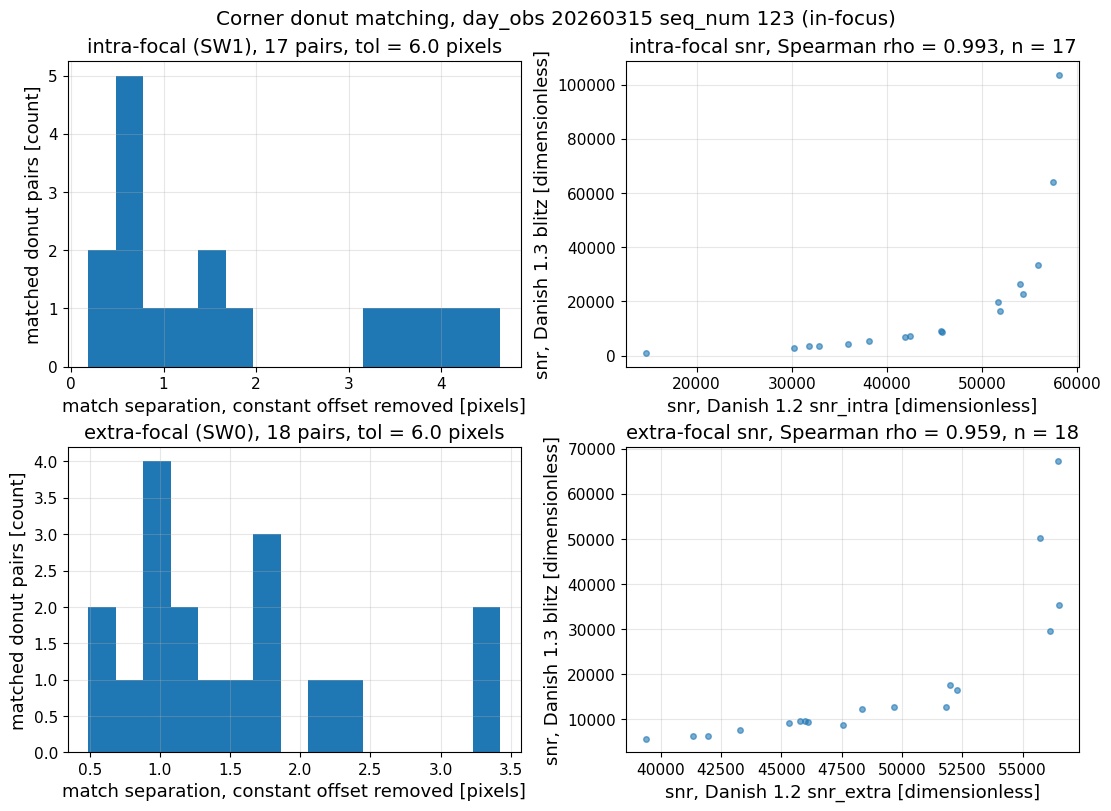

In [17]:
# Join the two per-side matches through their common Danish 1.2 row, so each Danish 1.2
# pair has a blitz estimate from BOTH of its member donuts. This subset carries the
# three-way comparison in section 8.
oi_i, bi_i = match['intra']['idx_old'], match['intra']['idx_blitz']
oi_e, bi_e = match['extra']['idx_old'], match['extra']['idx_blitz']
common_old = np.intersect1d(oi_i, oi_e)
to_intra = {int(o): int(b) for o, b in zip(oi_i, bi_i)}
to_extra = {int(o): int(b) for o, b in zip(oi_e, bi_e)}
bi_c = np.array([to_intra[int(o)] for o in common_old])
be_c = np.array([to_extra[int(o)] for o in common_old])
print(f'Danish 1.2 pairs matched on the intra (SW1) side : {len(oi_i)}')
print(f'Danish 1.2 pairs matched on the extra (SW0) side : {len(oi_e)}')
print(f'Danish 1.2 pairs matched on BOTH sides           : {len(common_old)}')
print(f'\nn = {len(common_old)} is the sample size for every three-way statistic in '
      'section 8.')

# The match separations, and the signal-to-noise ratio as an independent check that the
# matched rows really are the same donuts. The two snr columns are NOT the same
# quantity -- see the medians -- so the rank correlation is the meaningful statistic.
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, s in enumerate(('intra', 'extra')):
    m = match[s]
    half = 'SW1' if s == 'intra' else 'SW0'
    snr_col = f'snr_{s}'
    snr_o = np.asarray(old_ok[snr_col], dtype=float)[m['idx_old']]
    snr_b = np.asarray(blitz['snr'], dtype=float)[m['idx_blitz']]
    r, rho, n = corr_pair(snr_o, snr_b)
    print(f'\n{s}-focal ({half}) matched-donut signal-to-noise ratio '
          '(dimensionless, flux over noise):')
    print(f'    Pearson r = {r:.4f}, Spearman rho = {rho:.4f} (dimensionless), n = {n}')
    print(f'    median snr, Danish 1.2 {snr_col:10s} = {np.nanmedian(snr_o):10.1f} '
          '(dimensionless)')
    print(f'    median snr, Danish 1.3 blitz         = {np.nanmedian(snr_b):10.1f} '
          '(dimensionless)')
    axes[row, 0].hist(m['sep_pix'], bins=15)
    axes[row, 0].set_xlabel('match separation, constant offset removed [pixels]')
    axes[row, 0].set_ylabel('matched donut pairs [count]')
    axes[row, 0].set_title(f'{s}-focal ({half}), {len(m["idx_old"])} pairs, '
                           f'tol = {TOL_PIX} pixels')
    axes[row, 1].plot(snr_o, snr_b, 'o', ms=4, alpha=0.6)
    axes[row, 1].set_xlabel(f'snr, Danish 1.2 {snr_col} [dimensionless]')
    axes[row, 1].set_ylabel('snr, Danish 1.3 blitz [dimensionless]')
    axes[row, 1].set_title(f'{s}-focal snr, Spearman rho = {rho:.3f}, n = {n}')
fig.suptitle(f'Corner donut matching, day_obs {DAY_OBS} seq_num {SEQ_ACQ} (in-focus)')
plt.show()

<a id='zernike'></a>
## 8. Zernike Comparison, Reference Visit

This section is the reference visit alone, and its n = 15 pairs cannot carry a per-Noll
conclusion; section 10 repeats it on the pooled night. Both products give micrometres of wavefront in the Optical Coordinate System (OCS), so no
scaling and no rotation is applied. The intrinsic wavefront is a batoid model evaluation at
the donut's field position, so it tests the field-position and frame conventions; the
deviation is the fitted quantity and carries the estimator's noise.

The blitz is unpaired, so each half-sensor gives its own estimate: `SW1` (intra-focal) and
`SW0` (extra-focal) are compared separately against the single Danish 1.2 joint fit for the
pair, and then the mean of the two in section 8.1.

**One caution on the intrinsic comparison specific to the corner case.** In FAM the two
sides of focus look at the same star, so the intrinsic wavefront is evaluated at the same
field position on both and the comparison is exact. Here the two halves look at *different*
stars a few arcminutes apart, and Danish 1.2 reports one intrinsic per pair — presumably at
one of the two field positions or at their mean. So an intrinsic difference of the order of
the field-position gradient across the pair separation is **expected here and is not a
convention error**; the test is whether the difference is small compared to the intrinsic
itself, not whether it vanishes.

In [18]:
# Gather the matched Zernikes per side of focus, on the both-sides subset so that all
# three comparisons use the same Danish 1.2 pairs.
dev_old_c = np.asarray(old_ok[f'zk_deviation_{COORD_OLD}'], dtype=float)[common_old]
int_old_c = np.asarray(old_ok[f'zk_intrinsic_{COORD_OLD}'], dtype=float)[common_old]
dev_all_b = np.asarray(blitz[f'zk_deviation_{COORD_BLITZ}'], dtype=float)
int_all_b = np.asarray(blitz[f'zk_intrinsic_{COORD_BLITZ}'], dtype=float)

dev_int_c = dev_all_b[bi_c][:, NOLL]          # blitz intra-focal, SW1
dev_ext_c = dev_all_b[be_c][:, NOLL]          # blitz extra-focal, SW0
dev_mean_c = 0.5 * (dev_int_c + dev_ext_c)
int_int_c = int_all_b[bi_c][:, NOLL]
int_ext_c = int_all_b[be_c][:, NOLL]
int_mean_c = 0.5 * (int_int_c + int_ext_c)

print(f'matched Zernike arrays, {len(common_old)} Danish 1.2 pairs x {len(NOLL)} Noll:')
print(f'  Danish 1.2 zk_deviation_{COORD_OLD}  {dev_old_c.shape}')
print(f'  blitz intra (SW1)              {dev_int_c.shape}')
print(f'  blitz extra (SW0)              {dev_ext_c.shape}')

print('\nIntrinsic wavefront agreement (batoid model at the donut field position).')
for tag, v in (('intra (SW1)', int_int_c), ('extra (SW0)', int_ext_c),
               ('mean of both', int_mean_c)):
    d = v - int_old_c
    print(f'  {tag:14s}: median |Danish 1.3 - Danish 1.2| = '
          f'{np.nanmedian(np.abs(d)):.3e} um of wavefront')
print(f'  median |Danish 1.2 intrinsic| for scale = '
      f'{np.nanmedian(np.abs(int_old_c)):.4f} um of wavefront')
print(f'  ratio, median |difference| over median |intrinsic|, mean of both sides = '
      f'{np.nanmedian(np.abs(int_mean_c - int_old_c)) / np.nanmedian(np.abs(int_old_c)):.3e} '
      '(dimensionless)')
print('  The two blitz halves look at different stars, so a residual of order the field')
print('  gradient across the pair separation is expected; see the section note above.')

matched Zernike arrays, 15 Danish 1.2 pairs x 21 Noll:
  Danish 1.2 zk_deviation_OCS  (15, 21)
  blitz intra (SW1)              (15, 21)
  blitz extra (SW0)              (15, 21)

Intrinsic wavefront agreement (batoid model at the donut field position).
  intra (SW1)   : median |Danish 1.3 - Danish 1.2| = 9.941e-04 um of wavefront
  extra (SW0)   : median |Danish 1.3 - Danish 1.2| = 9.841e-04 um of wavefront
  mean of both  : median |Danish 1.3 - Danish 1.2| = 1.330e-06 um of wavefront
  median |Danish 1.2 intrinsic| for scale = 0.0122 um of wavefront
  ratio, median |difference| over median |intrinsic|, mean of both sides = 1.087e-04 (dimensionless)
  The two blitz halves look at different stars, so a residual of order the field
  gradient across the pair separation is expected; see the section note above.


In [19]:
# The three-way comparison, per Noll term: each blitz half alone, and the mean of the
# two, against the single Danish 1.2 joint fit. n is the same for all three columns.
def three_way(old_arr, i_arr, e_arr, m_arr):
    """Per-Noll comparison of three blitz estimates against one Danish 1.2 value.

    Parameters
    ----------
    old_arr : `numpy.ndarray`
        Danish 1.2 values, shape ``(n_pairs, 21)``, in µm of wavefront (OCS).
    i_arr, e_arr, m_arr : `numpy.ndarray`
        Blitz intra-focal, extra-focal and mean-of-both values, same shape and
        units.

    Returns
    -------
    table : `pandas.DataFrame`
        One row per Noll index, with the Danish 1.2 and blitz means in µm of
        wavefront, Pearson r and Spearman rho (dimensionless), the nMAD of the
        difference in µm of wavefront, and n.
    """
    rows = []
    for c, j in enumerate(NOLL):
        o = old_arr[:, c]
        rec = dict(noll=j, name=NOLL_NAMES.get(j, ''), mean_old=np.nanmean(o))
        for tag, v in (('intra', i_arr[:, c]), ('extra', e_arr[:, c]),
                       ('mean', m_arr[:, c])):
            r, rho, n = corr_pair(o, v)
            rec[f'mean_blitz_{tag}'] = np.nanmean(v)
            rec[f'r_{tag}'] = r
            rec[f'rho_{tag}'] = rho
            rec[f'nmad_{tag}'] = nmad(v - o)
            rec['n'] = n
        rows.append(rec)
    return pd.DataFrame(rows)


dev_compare = three_way(dev_old_c, dev_int_c, dev_ext_c, dev_mean_c)
COLS = ['noll', 'name', 'mean_old', 'mean_blitz_intra', 'mean_blitz_extra',
        'mean_blitz_mean', 'r_intra', 'r_extra', 'r_mean',
        'rho_intra', 'rho_extra', 'rho_mean',
        'nmad_intra', 'nmad_extra', 'nmad_mean', 'n']
print('DEVIATION Zernike: each blitz corner half alone, and the mean of the two, against '
      'the')
print('Danish 1.2 paired joint fit. Means and nMAD are in um of wavefront (OCS); r and '
      'rho are')
print(f'dimensionless; n = {len(common_old)} Danish 1.2 pairs throughout.')
with pd.option_context('display.max_rows', 30, 'display.width', 250,
                       'display.float_format', lambda v: f'{v:8.4f}'):
    display(dev_compare[COLS])

DEVIATION Zernike: each blitz corner half alone, and the mean of the two, against the
Danish 1.2 paired joint fit. Means and nMAD are in um of wavefront (OCS); r and rho are
dimensionless; n = 15 Danish 1.2 pairs throughout.


,noll,name,mean_old,mean_blitz_intra,mean_blitz_extra,mean_blitz_mean,r_intra,r_extra,r_mean,rho_intra,rho_extra,rho_mean,nmad_intra,nmad_extra,nmad_mean,n
0,4,Defocus,-0.4316,-0.3451,-0.5320,-0.4386,0.9669,0.9553,0.9679,0.8786,0.8464,0.9179,0.0536,0.0661,0.0147,15
1,5,Astig45,0.1034,0.0546,0.2053,0.1300,0.9088,0.9642,0.9613,0.8250,0.8893,0.9393,0.2643,0.0980,0.1341,15
2,6,Astig0,-0.3976,-0.5331,-0.4887,-0.5109,0.6267,0.7740,0.9209,0.6571,0.7000,0.9036,0.2687,0.1555,0.1032,15
3,7,Coma_y,0.3422,0.4588,0.3083,0.3835,0.7980,0.5396,0.8558,0.8036,0.5571,0.8393,0.1079,0.1173,0.0995,15
4,8,Coma_x,0.0811,0.1245,0.0726,0.0986,0.9188,0.8516,0.9536,0.8857,0.8893,0.9321,0.1238,0.1000,0.0437,15
5,9,Trefoil_y,0.0138,0.0581,-0.0216,0.0182,0.3812,0.9612,0.9368,0.4286,0.9357,0.9536,0.1427,0.0672,0.0357,15
6,10,Trefoil_x,0.0241,0.0595,-0.0517,0.0039,0.8108,0.5425,0.8677,0.8321,0.5714,0.9143,0.1543,0.1372,0.0537,15
7,11,Spherical,0.1645,0.3387,0.0714,0.2050,0.6138,0.6047,0.6122,0.6679,0.6321,0.5821,0.0737,0.0714,0.0664,15
8,12,2ndAstig0,-0.1441,-0.1292,-0.1199,-0.1245,0.5785,0.9503,0.9564,0.6000,0.8000,0.9607,0.0520,0.0250,0.0112,15
9,13,2ndAstig45,-0.0375,-0.0232,-0.0215,-0.0224,0.6107,0.9275,0.9319,0.6536,0.8393,0.9679,0.1008,0.0351,0.0342,15


In [20]:
int_compare = three_way(int_old_c, int_int_c, int_ext_c, int_mean_c)
print('INTRINSIC Zernike, the same three-way comparison. Means and nMAD in um of '
      'wavefront')
print(f'(OCS); r and rho dimensionless; n = {len(common_old)} Danish 1.2 pairs.')
with pd.option_context('display.max_rows', 30, 'display.width', 250,
                       'display.float_format', lambda v: f'{v:8.4f}'):
    display(int_compare[COLS])

INTRINSIC Zernike, the same three-way comparison. Means and nMAD in um of wavefront
(OCS); r and rho dimensionless; n = 15 Danish 1.2 pairs.


,noll,name,mean_old,mean_blitz_intra,mean_blitz_extra,mean_blitz_mean,r_intra,r_extra,r_mean,rho_intra,rho_extra,rho_mean,nmad_intra,nmad_extra,nmad_mean,n
0,4,Defocus,-0.0431,-0.0617,-0.0246,-0.0431,0.7822,0.3950,0.9999,0.8179,0.0714,0.9964,0.0726,0.0736,0.0006,15
1,5,Astig45,0.0336,0.0445,0.0227,0.0336,0.9414,0.8580,1.0000,0.9250,0.8214,1.0000,0.0153,0.0155,0.0000,15
2,6,Astig0,0.0196,0.0189,0.0204,0.0196,0.9818,0.9712,1.0000,0.8750,0.9500,1.0000,0.0040,0.0039,0.0000,15
3,7,Coma_y,0.0002,0.0012,-0.0007,0.0003,0.9894,0.9825,1.0000,0.9464,0.9929,1.0000,0.0031,0.0031,0.0000,15
4,8,Coma_x,0.0113,0.0104,0.0122,0.0113,0.9856,0.9777,1.0000,0.9214,0.9964,1.0000,0.0037,0.0036,0.0000,15
5,9,Trefoil_y,0.0358,0.0383,0.0332,0.0358,0.9921,0.9922,1.0000,0.9179,0.8464,1.0000,0.0121,0.0121,0.0000,15
6,10,Trefoil_x,-0.0113,-0.0071,-0.0155,-0.0113,0.9960,0.9943,1.0000,0.9143,0.8643,1.0000,0.0102,0.0101,0.0000,15
7,11,Spherical,-0.0358,-0.0387,-0.0329,-0.0358,0.8059,0.8392,1.0000,0.7821,0.8643,1.0000,0.0026,0.0026,0.0000,15
8,12,2ndAstig0,-0.0018,-0.0020,-0.0016,-0.0018,0.9940,0.9940,1.0000,0.9857,0.9714,1.0000,0.0004,0.0004,0.0000,15
9,13,2ndAstig45,-0.0016,-0.0010,-0.0023,-0.0016,0.9899,0.9928,1.0000,0.9429,0.9679,1.0000,0.0013,0.0013,0.0000,15


In [21]:
# The intrinsic table above shows something worth testing outright rather than reading
# off a table: the MEAN of the two blitz halves reproduces the Danish 1.2 per-pair
# intrinsic essentially exactly, while either half alone does not. If true, the Danish
# 1.2 intrinsic for a pair is the arithmetic mean of the two donuts' own field-position
# evaluations, which is what makes the mean-of-both the right like-for-like comparison.
d_mean = int_mean_c - int_old_c
d_half = 0.5 * (int_int_c - int_ext_c)      # half the separation between the two halves
print('Intrinsic Zernike, mean of the two blitz halves against the Danish 1.2 per-pair '
      'intrinsic:')
print(f'  maximum |mean of both - Danish 1.2| over all '
      f'{d_mean.size} (pair, Noll) entries = {np.nanmax(np.abs(d_mean)):.3e} '
      'um of wavefront')
print(f'  median  |mean of both - Danish 1.2|                   = '
      f'{np.nanmedian(np.abs(d_mean)):.3e} um of wavefront')
print(f'  for scale, median |half the difference between the two halves| = '
      f'{np.nanmedian(np.abs(d_half)):.4f} um of wavefront')
print(f'  ratio of the two, residual over half-separation = '
      f'{np.nanmedian(np.abs(d_mean)) / np.nanmedian(np.abs(d_half)):.2e} '
      '(dimensionless)')
print(f'  Pearson r of (mean of both) against Danish 1.2, minimum over the '
      f'{len(NOLL)} Noll terms = {int_compare["r_mean"].min():.6f} (dimensionless), '
      f'n = {len(common_old)}')
print()
print('So the Danish 1.2 per-pair intrinsic IS the mean of the two donuts field-position')
print('evaluations, to a residual orders of magnitude below the separation between the')
print('two halves. Two things follow:')
print('  1. the units, the Noll indexing and the OCS frame match EXACTLY between the two')
print('     reductions -- this is the tight convention test, and it passes;')
print('  2. averaging the two blitz halves is not an approximation to what Danish 1.2')
print('     does with the field position, it is exactly what Danish 1.2 does.')

Intrinsic Zernike, mean of the two blitz halves against the Danish 1.2 per-pair intrinsic:
  maximum |mean of both - Danish 1.2| over all 315 (pair, Noll) entries = 1.556e-03 um of wavefront
  median  |mean of both - Danish 1.2|                   = 1.330e-06 um of wavefront
  for scale, median |half the difference between the two halves| = 0.0010 um of wavefront
  ratio of the two, residual over half-separation = 1.35e-03 (dimensionless)
  Pearson r of (mean of both) against Danish 1.2, minimum over the 21 Noll terms = 0.999866 (dimensionless), n = 15

So the Danish 1.2 per-pair intrinsic IS the mean of the two donuts field-position
evaluations, to a residual orders of magnitude below the separation between the
two halves. Two things follow:
  1. the units, the Noll indexing and the OCS frame match EXACTLY between the two
     reductions -- this is the tight convention test, and it passes;
  2. averaging the two blitz halves is not an approximation to what Danish 1.2
     does with the

<a id='zernike-mean'></a>
### 8.1 The mean of the two unpaired sides against the Danish 1.2 joint fit

Each single-half comparison above pits one unpaired blitz donut against a Danish 1.2 value
fitted jointly from **both** donuts of the pair, so the blitz side is using half the
information by construction. Averaging the `SW1` and `SW0` blitz estimates for the same
Danish 1.2 pair is the like-for-like comparison: the same two donut images then go into
both numbers.

Note the difference from the FAM case once more: here the average is over **two different
stars**, not two exposures of one star, so a gain over the single sides shows that the two
halves carry a **common** wavefront signal — which is exactly the physical claim the corner
sensors rest on — rather than showing noise averaging down on a repeated measurement.

In [22]:
print('Median over the 21 fitted Noll terms, deviation Zernike, '
      f'n = {len(common_old)} Danish 1.2 pairs:')
for tag, lbl in (('intra', 'intra only (SW1)'), ('extra', 'extra only (SW0)'),
                 ('mean', 'mean of the two halves')):
    print(f'  {lbl:24s}: Pearson r = {dev_compare[f"r_{tag}"].median():.4f}, '
          f'Spearman rho = {dev_compare[f"rho_{tag}"].median():.4f} (dimensionless), '
          f'nMAD of the difference = {dev_compare[f"nmad_{tag}"].median():.4f} '
          'um of wavefront')

# If the per-half disagreement were independent noise, averaging two estimates would
# improve the scatter by 1/sqrt(2) = 0.707 (dimensionless). Beating that means the two
# halves are biased in OPPOSITE directions and cancel on averaging.
for ref in ('intra', 'extra'):
    ratio = (dev_compare['nmad_mean'].median()
             / dev_compare[f'nmad_{ref}'].median())
    print(f'\nRatio of the median nMAD, mean of both halves over {ref} alone = '
          f'{ratio:.3f} (dimensionless).')
print('A pure-noise average of two independent estimates would give '
      '1/sqrt(2) = 0.707 (dimensionless).')

print('\nPer-half mean offset from Danish 1.2, and whether the two halves straddle it '
      '[um of wavefront, OCS]:')
d_i = dev_compare['mean_blitz_intra'] - dev_compare['mean_old']
d_e = dev_compare['mean_blitz_extra'] - dev_compare['mean_old']
straddle = int(((d_i * d_e) < 0).sum())
print(f'  the two halves fall on opposite sides of the Danish 1.2 mean on {straddle} '
      f'of {len(dev_compare)} Noll terms')
for j in (4, 5, 6, 11, 14):
    row = dev_compare[dev_compare['noll'] == j].iloc[0]
    print(f'  {zk_label(j):18s}: Danish 1.2 {row["mean_old"]:+.4f}, '
          f'blitz intra (SW1) {row["mean_blitz_intra"]:+.4f}, '
          f'extra (SW0) {row["mean_blitz_extra"]:+.4f}, '
          f'mean {row["mean_blitz_mean"]:+.4f}  [um of wavefront]')

# The best and worst terms after averaging. On n = 15 pairs the ORDERING is not
# significant -- reported only to say where to look next, not as a ranking.
srt = dev_compare.sort_values('r_mean')
print(f'\nWeakest three Noll terms for the mean of both halves (n = {len(common_old)}, '
      'so the ordering is NOT significant):')
for _, row in srt.head(3).iterrows():
    print(f'  {zk_label(int(row["noll"])):18s}: Pearson r = {row["r_mean"]:.4f}, '
          f'Spearman rho = {row["rho_mean"]:.4f} (dimensionless), '
          f'nMAD = {row["nmad_mean"]:.4f} um of wavefront')
print('Strongest three:')
for _, row in srt.tail(3).iloc[::-1].iterrows():
    print(f'  {zk_label(int(row["noll"])):18s}: Pearson r = {row["r_mean"]:.4f}, '
          f'Spearman rho = {row["rho_mean"]:.4f} (dimensionless), '
          f'nMAD = {row["nmad_mean"]:.4f} um of wavefront')

Median over the 21 fitted Noll terms, deviation Zernike, n = 15 Danish 1.2 pairs:
  intra only (SW1)        : Pearson r = 0.7052, Spearman rho = 0.6964 (dimensionless), nMAD of the difference = 0.0520 um of wavefront
  extra only (SW0)        : Pearson r = 0.8516, Spearman rho = 0.8000 (dimensionless), nMAD of the difference = 0.0250 um of wavefront
  mean of the two halves  : Pearson r = 0.9035, Spearman rho = 0.8964 (dimensionless), nMAD of the difference = 0.0191 um of wavefront

Ratio of the median nMAD, mean of both halves over intra alone = 0.367 (dimensionless).

Ratio of the median nMAD, mean of both halves over extra alone = 0.764 (dimensionless).
A pure-noise average of two independent estimates would give 1/sqrt(2) = 0.707 (dimensionless).

Per-half mean offset from Danish 1.2, and whether the two halves straddle it [um of wavefront, OCS]:
  the two halves fall on opposite sides of the Danish 1.2 mean on 14 of 21 Noll terms
  Z4 Defocus        : Danish 1.2 -0.4316, blitz int

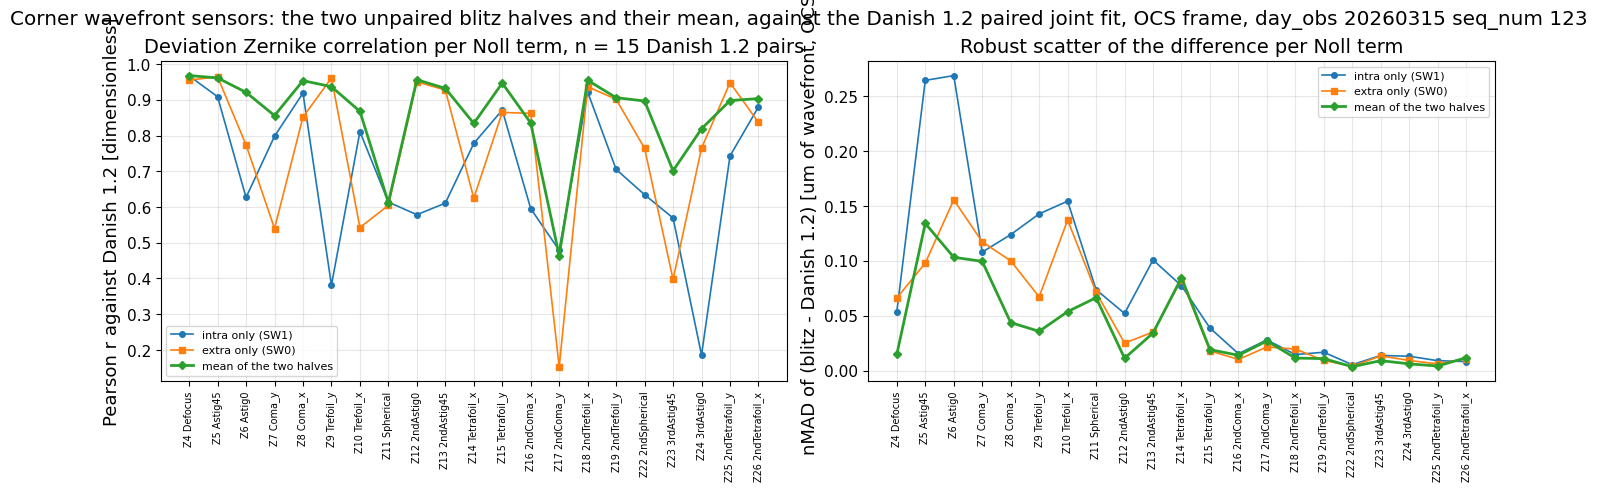

In [23]:
# Left: the correlation against Danish 1.2 per Noll, each half alone and the mean of
# the two. Right: the robust scatter of the difference, same three cases.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
xs = np.arange(len(NOLL))
for key, mk, lbl, lw in (('intra', 'o-', 'intra only (SW1)', 1.2),
                         ('extra', 's-', 'extra only (SW0)', 1.2),
                         ('mean', 'D-', 'mean of the two halves', 2.0)):
    axes[0].plot(xs, dev_compare[f'r_{key}'], mk, ms=4, lw=lw, label=lbl)
    axes[1].plot(xs, dev_compare[f'nmad_{key}'], mk, ms=4, lw=lw, label=lbl)
axes[0].set_ylabel('Pearson r against Danish 1.2 [dimensionless]')
axes[0].set_title(f'Deviation Zernike correlation per Noll term, '
                  f'n = {len(common_old)} Danish 1.2 pairs')
axes[1].set_ylabel('nMAD of (blitz - Danish 1.2) [um of wavefront, OCS]')
axes[1].set_title('Robust scatter of the difference per Noll term')
for ax in axes:
    ax.set_xticks(xs)
    ax.set_xticklabels([zk_label(j) for j in NOLL], rotation=90, fontsize=7)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle(f'Corner wavefront sensors: the two unpaired blitz halves and their mean, '
             f'against the Danish 1.2 paired joint fit, {COORD_OLD} frame, '
             f'day_obs {DAY_OBS} seq_num {SEQ_ACQ}')
plt.show()

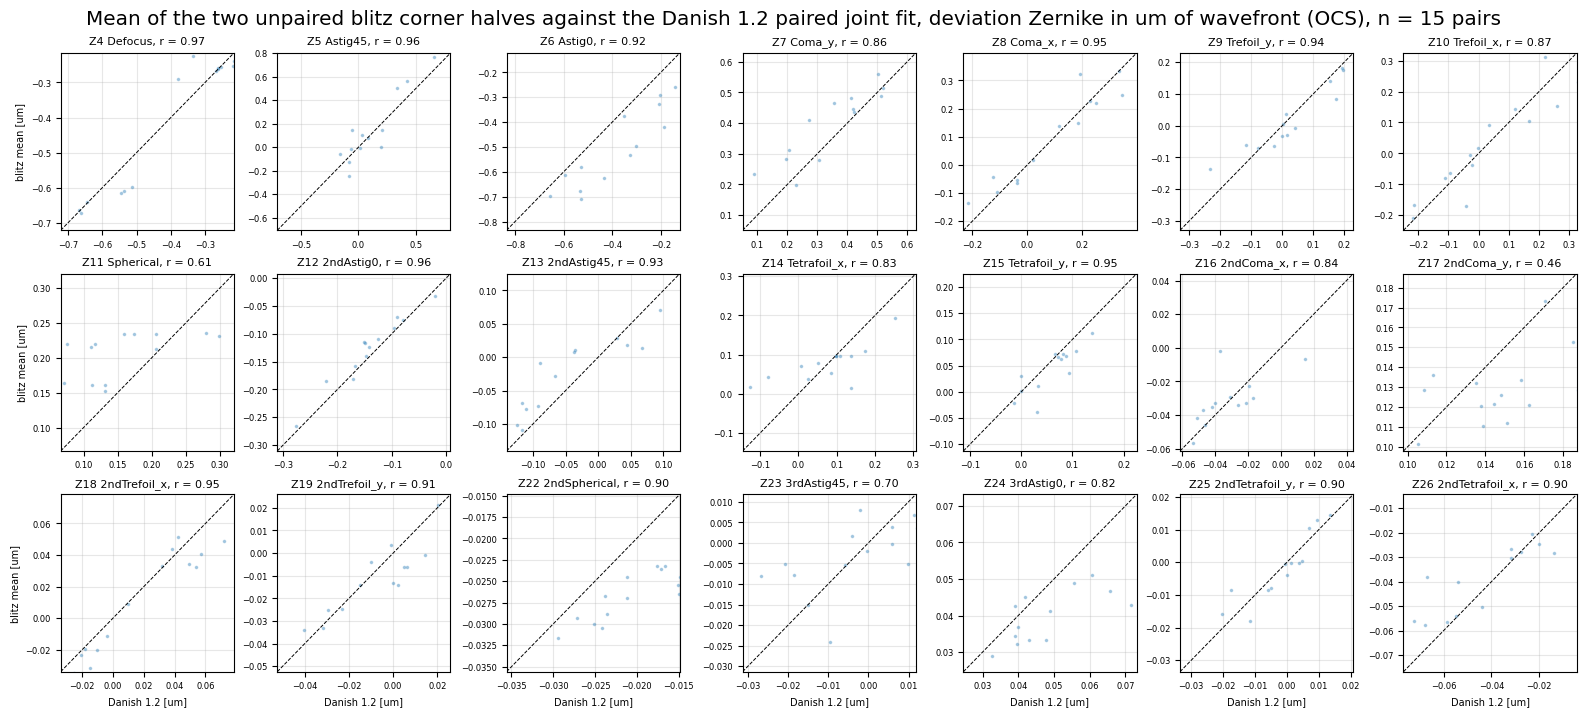

In [24]:
# Per-Noll one-to-one scatter of the mean of the two halves against Danish 1.2.
ncol = 7
nrow = int(np.ceil(len(NOLL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.25 * ncol, 2.35 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    o = dev_old_c[:, c]
    m = dev_mean_c[:, c]
    good = np.isfinite(o) & np.isfinite(m)
    # Pooled 1st-to-99th percentile RANGE over both axes, not a symmetric limit about
    # zero: several terms carry a real mean offset, so a symmetric frame would push the
    # cloud into a corner instead of filling the panel. This clips roughly 1 to 2 per
    # cent of the points, so these panels are NOT where outliers show up; every
    # statistic in the tables above is computed on the unclipped arrays.
    lolim, hilim = np.nanpercentile(np.concatenate([o[good], m[good]]), [1.0, 99.0])
    ax.plot(o[good], m[good], 'o', ms=1.6, alpha=0.3)
    ax.plot([lolim, hilim], [lolim, hilim], 'k--', lw=0.7)
    ax.set_xlim(lolim, hilim)
    ax.set_ylim(lolim, hilim)
    ax.set_title(f'{zk_label(j)}, r = {dev_compare["r_mean"].iloc[c]:.2f}', fontsize=8)
    ax.tick_params(labelsize=6)
    if c % ncol == 0:
        ax.set_ylabel('blitz mean [um]', fontsize=7)
    if c // ncol == nrow - 1:
        ax.set_xlabel('Danish 1.2 [um]', fontsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.axis('off')
fig.suptitle('Mean of the two unpaired blitz corner halves against the Danish 1.2 '
             f'paired joint fit, deviation Zernike in um of wavefront ({COORD_OLD}), '
             f'n = {len(common_old)} pairs')
plt.show()

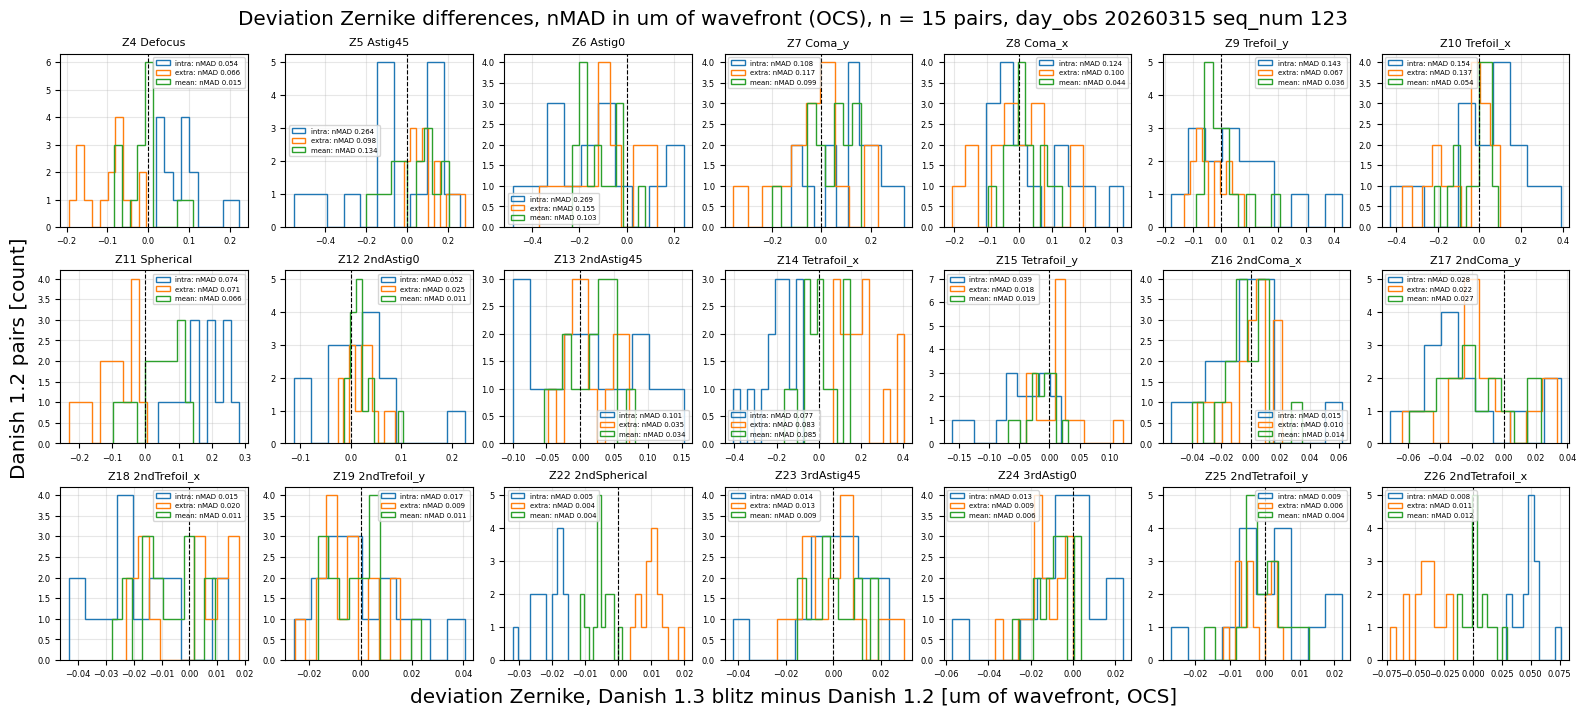

In [25]:
# Per-Noll difference distributions, with the robust scatter annotated. On n = 15
# pairs these are more a display of the individual values than a distribution.
fig, axes = plt.subplots(nrow, ncol, figsize=(2.25 * ncol, 2.35 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    for tag, v in (('intra', dev_int_c), ('extra', dev_ext_c), ('mean', dev_mean_c)):
        d = v[:, c] - dev_old_c[:, c]
        d = d[np.isfinite(d)]
        if len(d):
            ax.hist(d, bins=10, histtype='step', label=f'{tag}: nMAD {nmad(d):.3f}')
    ax.axvline(0.0, color='k', ls='--', lw=0.8)
    ax.set_title(zk_label(j), fontsize=8)
    ax.legend(fontsize=5)
    ax.tick_params(labelsize=6)
for ax in axes.flat[len(NOLL):]:
    ax.axis('off')
fig.supxlabel('deviation Zernike, Danish 1.3 blitz minus Danish 1.2 '
              '[um of wavefront, OCS]')
fig.supylabel('Danish 1.2 pairs [count]')
fig.suptitle(f'Deviation Zernike differences, nMAD in um of wavefront (OCS), '
             f'n = {len(common_old)} pairs, day_obs {DAY_OBS} seq_num {SEQ_ACQ}')
plt.show()

<a id='blur'></a>
## 9. Donut Width and Signal-to-Noise Comparison

The FAM notebook compared the blitz `group_fwhm` against the Danish 1.2 `blur`. **That
comparison cannot be made here: the Danish 1.2 corner `aggregateAOSVisitTableRaw` has no
`blur` column at all.** The FAM notebook got one because it read the table through
`intrinsics_lib.get_aggregate_zernikes`, which adds `blur` from the per-donut
`estimatorInfo` diagnostics; the raw corner dataset carries `estimatorInfo` in its
metadata but no `blur` column, and nothing here adds one.

So this section reports what the two products actually both have: the blitz `group_fwhm`
distribution on its own, and the `snr` columns, which the two pipelines measure
independently. It does not invent a Danish 1.2 counterpart to `group_fwhm`.

In [26]:
print(f"'blur' in the Danish 1.2 corner table columns: {'blur' in old.colnames}")
print(f"columns whose name contains 'blur' or 'fwhm':")
print(f"  Danish 1.2: {[c for c in old.colnames if 'blur' in c.lower() or 'fwhm' in c.lower()]}")
print(f"  blitz     : {[c for c in blitz.colnames if 'blur' in c.lower() or 'fwhm' in c.lower()]}")
_est = old.meta.get('estimatorInfo')
print(f"\nDanish 1.2 meta['estimatorInfo'] keys: "
      f"{sorted(_est) if hasattr(_est, 'keys') else type(_est).__name__}")
print('So there is no Danish 1.2 donut-width column to compare against, and none is '
      'invented here.')

'blur' in the Danish 1.2 corner table columns: False
columns whose name contains 'blur' or 'fwhm':
  Danish 1.2: []
  blitz     : ['group_fwhm']

Danish 1.2 meta['estimatorInfo'] keys: ['blur_clipped', 'chi_square', 'exception_status', 'fit_success', 'fwhm', 'lstsq_cost', 'lstsq_nfev', 'lstsq_njev', 'lstsq_optimality', 'lstsq_status', 'lstsq_success', 'model_bkg', 'model_dx', 'model_dy', 'model_flux']
So there is no Danish 1.2 donut-width column to compare against, and none is invented here.


blitz group_fwhm unit as carried by the table: arcsec
  intra (SW1)   : median = 1.0022 arcsec, 5th to 95th percentile 0.9474 to 1.1231 arcsec, n = 15
  extra (SW0)   : median = 0.8045 arcsec, 5th to 95th percentile 0.7754 to 0.8288 arcsec, n = 15
  mean of both  : median = 0.9062 arcsec, 5th to 95th percentile 0.8596 to 0.9694 arcsec, n = 15

group_fwhm, SW1 against SW0 within the same Danish 1.2 pair: Pearson r = 0.4848, Spearman rho = 0.5857 (dimensionless), n = 15.
These are two DIFFERENT stars on two different CCDs, so this measures how far the
donut width is common across a corner raft, not a repeatability.

snr (dimensionless, flux over noise), the one measured quantity both products carry:
  intra (SW1)   : Pearson r = 0.7346, Spearman rho = 0.9929 (dimensionless), n = 15
                  median Danish 1.2 =    42448.4, median blitz =     7114.4 (both dimensionless)
                  ratio of medians, Danish 1.2 over blitz = 5.97 (dimensionless)
  extra (SW0)   : Pearson r = 0

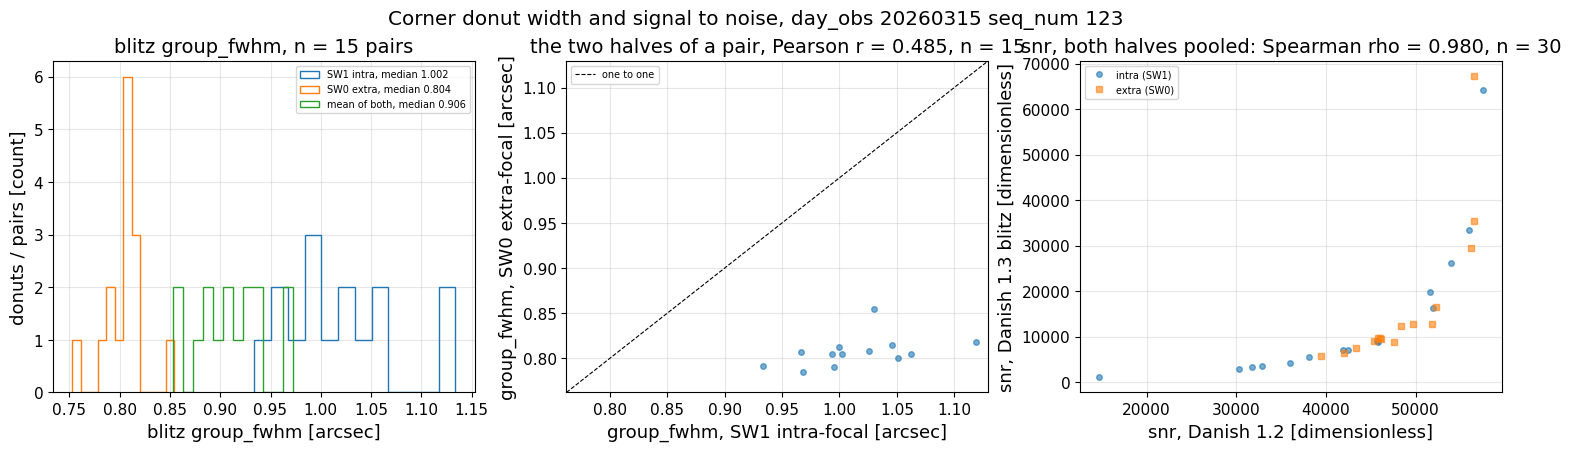

In [27]:
# What the blitz group_fwhm looks like on the two corner halves, on the matched pairs.
fwhm_all = np.asarray(blitz['group_fwhm'], dtype=float)
fw_i = fwhm_all[bi_c]
fw_e = fwhm_all[be_c]
fw_mean = 0.5 * (fw_i + fw_e)
unit_fwhm = blitz['group_fwhm'].unit
print(f'blitz group_fwhm unit as carried by the table: {unit_fwhm}')
for tag, v in (('intra (SW1)', fw_i), ('extra (SW0)', fw_e), ('mean of both', fw_mean)):
    print(f'  {tag:14s}: median = {np.nanmedian(v):.4f} arcsec, '
          f'5th to 95th percentile {np.nanpercentile(v, 5):.4f} to '
          f'{np.nanpercentile(v, 95):.4f} arcsec, n = {int(np.isfinite(v).sum())}')
r_ie, rho_ie, n_ie = corr_pair(fw_i, fw_e)
print(f'\ngroup_fwhm, SW1 against SW0 within the same Danish 1.2 pair: '
      f'Pearson r = {r_ie:.4f}, Spearman rho = {rho_ie:.4f} (dimensionless), n = {n_ie}.')
print('These are two DIFFERENT stars on two different CCDs, so this measures how far the')
print('donut width is common across a corner raft, not a repeatability.')

# The snr columns, which both products do have.
snr_b_i = np.asarray(blitz['snr'], dtype=float)[bi_c]
snr_b_e = np.asarray(blitz['snr'], dtype=float)[be_c]
snr_o_i = np.asarray(old_ok['snr_intra'], dtype=float)[common_old]
snr_o_e = np.asarray(old_ok['snr_extra'], dtype=float)[common_old]
print('\nsnr (dimensionless, flux over noise), the one measured quantity both products '
      'carry:')
for tag, o, b in (('intra (SW1)', snr_o_i, snr_b_i), ('extra (SW0)', snr_o_e, snr_b_e)):
    r, rho, n = corr_pair(o, b)
    print(f'  {tag:14s}: Pearson r = {r:.4f}, Spearman rho = {rho:.4f} '
          f'(dimensionless), n = {n}')
    print(f'                  median Danish 1.2 = {np.nanmedian(o):10.1f}, '
          f'median blitz = {np.nanmedian(b):10.1f} (both dimensionless)')
    print(f'                  ratio of medians, Danish 1.2 over blitz = '
          f'{np.nanmedian(o) / np.nanmedian(b):.2f} (dimensionless)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].hist(fw_i[np.isfinite(fw_i)], bins=12, histtype='step',
             label=f'SW1 intra, median {np.nanmedian(fw_i):.3f}')
axes[0].hist(fw_e[np.isfinite(fw_e)], bins=12, histtype='step',
             label=f'SW0 extra, median {np.nanmedian(fw_e):.3f}')
axes[0].hist(fw_mean[np.isfinite(fw_mean)], bins=12, histtype='step',
             label=f'mean of both, median {np.nanmedian(fw_mean):.3f}')
axes[0].set_xlabel('blitz group_fwhm [arcsec]')
axes[0].set_ylabel('donuts / pairs [count]')
axes[0].set_title(f'blitz group_fwhm, n = {len(common_old)} pairs')
axes[0].legend(fontsize=7)

lo, hi = np.nanpercentile(np.concatenate([fw_i, fw_e]), [1.0, 99.0])
axes[1].plot(fw_i, fw_e, 'o', ms=4, alpha=0.6)
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='one to one')
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)
axes[1].set_xlabel('group_fwhm, SW1 intra-focal [arcsec]')
axes[1].set_ylabel('group_fwhm, SW0 extra-focal [arcsec]')
axes[1].set_title(f'the two halves of a pair, Pearson r = {r_ie:.3f}, n = {n_ie}')
axes[1].legend(fontsize=7)

r_s, rho_s, n_s = corr_pair(np.concatenate([snr_o_i, snr_o_e]),
                            np.concatenate([snr_b_i, snr_b_e]))
axes[2].plot(snr_o_i, snr_b_i, 'o', ms=4, alpha=0.6, label='intra (SW1)')
axes[2].plot(snr_o_e, snr_b_e, 's', ms=4, alpha=0.6, label='extra (SW0)')
axes[2].set_xlabel('snr, Danish 1.2 [dimensionless]')
axes[2].set_ylabel('snr, Danish 1.3 blitz [dimensionless]')
axes[2].set_title(f'snr, both halves pooled: Spearman rho = {rho_s:.3f}, n = {n_s}')
axes[2].legend(fontsize=7)
fig.suptitle(f'Corner donut width and signal to noise, day_obs {DAY_OBS} '
             f'seq_num {SEQ_ACQ}')
plt.show()

<a id='allvisits'></a>
## 10. All Visits of the Night

Everything above is one visit. With 15 Danish 1.2 pairs that is enough to establish the
*structure* — the conventions, the pairing, the traps — but not to rank Noll terms or to
trust a Pearson r. This section runs the identical match and the identical comparison over
all 62 comparable visits of `day_obs = 20260315` and pools the result.

The loop does exactly what sections 7 and 8 did, with nothing relaxed:

- one Butler read per product per visit, no re-reading inside inner loops;
- the same cuts, `used == True` on Danish 1.2 and `group_fit_success` on the blitz;
- the same match on `det_id` plus pixel position, one side of focus at a time, at the same
  `TOL_PIX`;
- the centroid offset **measured per visit**, not taken from the reference visit. Whether
  those offsets are in fact constant across the night is then a result, reported in
  section 10.2, rather than an assumption.

Every per-visit read is wrapped, and any visit that raises or comes back degenerate is
collected and **reported** rather than silently dropped — a silent skip would quietly change
which sample the statistics describe. Every pooled row carries its `visit`, `seq_num` and
`det_name`, so anything below can be split per visit or per corner raft.

In [28]:
def match_visit(visit):
    """Match the blitz and Danish 1.2 corner products for one visit.

    Applies the same cuts and the same det_id-plus-pixel-position match as sections 7
    and 8, measuring the centroid offset from this visit's own data.

    Parameters
    ----------
    visit : `int`
        Visit id, ``day_obs * 100000 + seq_num``.

    Returns
    -------
    summary : `dict`
        Per-visit diagnostics: row counts, the measured centroid offset ``dx`` / ``dy``
        in detector pixels and the median match separation in pixels on each side, and
        the number of Danish 1.2 pairs matched on each side and on both.
    pooled : `dict` or `None`
        Per-pair arrays for the pairs matched on both sides -- the Zernikes in µm of
        wavefront (OCS), plus ``visit``, ``seq_num`` and ``det_name`` labels. `None`
        when no pair matched on both sides.

    Raises
    ------
    RuntimeError
        If the table is degenerate: no ``used`` Danish 1.2 row, no fitted blitz row, or
        a ``defocal_offsets`` column that does not vary in exactly one element.
    """
    zz = butler.get(DATASET_BLITZ, collections=COLL_BLITZ, instrument='LSSTCam',
                    visit=visit, parameters=KEEP_META)
    oo = butler.get(DATASET_OLD, collections=COLL_OLD, instrument='LSSTCam',
                    visit=visit)

    used = np.asarray(oo['used'], dtype=bool)
    oo = oo[used]
    fitted = np.asarray(zz['group_fit_success'], dtype=bool)
    if len(oo) == 0 or int(fitted.sum()) == 0:
        raise RuntimeError(f'degenerate: {len(oo)} used Danish 1.2 rows, '
                           f'{int(fitted.sum())} fitted blitz rows')
    sides, _ = focus_side(zz)          # raises if defocal_offsets is degenerate

    summary = dict(visit=visit, seq_num=visit % 100000, n_old_used=len(oo),
                   n_blitz=len(zz), n_blitz_fitted=int(fitted.sum()))
    per_side = {}
    for s, cx, cy, dcol in (
            ('intra', 'centroid_x_intra', 'centroid_y_intra', 'intra_donut_id'),
            ('extra', 'centroid_x_extra', 'centroid_y_extra', 'extra_donut_id')):
        rows_b = np.where((sides == s) & fitted)[0]
        i_o, i_b, sep, shift = match_one_side(
            zz, parse_det_id(oo[dcol]), np.asarray(oo[cx], dtype=float),
            np.asarray(oo[cy], dtype=float), rows_b, tol_pix=TOL_PIX)
        keep = deduplicate(i_o, i_b, sep)
        i_o, i_b, sep = i_o[keep], i_b[keep], sep[keep]
        per_side[s] = (i_o, i_b)
        summary[f'n_{s}'] = len(i_o)
        summary[f'dx_{s}'], summary[f'dy_{s}'] = shift
        summary[f'sep_{s}'] = float(np.median(sep)) if len(sep) else np.nan

    oi, bi = per_side['intra']
    oe, be = per_side['extra']
    common = np.intersect1d(oi, oe)
    summary['n_both'] = len(common)
    if len(common) == 0:
        return summary, None

    to_i = {int(a): int(c) for a, c in zip(oi, bi)}
    to_e = {int(a): int(c) for a, c in zip(oe, be)}
    ci = np.array([to_i[int(x)] for x in common])
    ce = np.array([to_e[int(x)] for x in common])
    dev_b = np.asarray(zz[f'zk_deviation_{COORD_BLITZ}'], dtype=float)
    int_b = np.asarray(zz[f'zk_intrinsic_{COORD_BLITZ}'], dtype=float)
    names = np.asarray(zz['det_name'], dtype=str)
    pooled = dict(
        visit=np.full(len(common), visit, dtype=np.int64),
        seq_num=np.full(len(common), visit % 100000, dtype=np.int64),
        raft=np.array([n.split('_')[0] for n in names[ce]]),
        dev_old=np.asarray(oo[f'zk_deviation_{COORD_OLD}'], dtype=float)[common],
        int_old=np.asarray(oo[f'zk_intrinsic_{COORD_OLD}'], dtype=float)[common],
        dev_intra=dev_b[ci][:, NOLL], dev_extra=dev_b[ce][:, NOLL],
        int_intra=int_b[ci][:, NOLL], int_extra=int_b[ce][:, NOLL],
        fwhm_intra=np.asarray(zz['group_fwhm'], dtype=float)[ci],
        fwhm_extra=np.asarray(zz['group_fwhm'], dtype=float)[ce])
    return summary, pooled


import time

t_start = time.time()
summaries, chunks, failures = [], [], []
for k, v in enumerate(VISITS):
    try:
        summary, pooled = match_visit(v)
    except Exception as exc:
        failures.append(dict(visit=v, seq_num=v % 100000,
                             error=f'{type(exc).__name__}: {exc}'))
        continue
    summaries.append(summary)
    if pooled is not None:
        chunks.append(pooled)
    if (k + 1) % 10 == 0 or k == len(VISITS) - 1:
        print(f'  {k + 1:3d} / {len(VISITS)} visits, '
              f'{sum(s["n_both"] for s in summaries):5d} pairs matched on both sides, '
              f'{len(failures)} failures, {time.time() - t_start:5.0f} s elapsed',
              flush=True)

print(f'\nloop finished in {time.time() - t_start:.0f} s')
print(f'visits processed successfully : {len(summaries)} of {len(VISITS)}')
print(f'visits that failed            : {len(failures)}')
for f in failures:
    print(f'    seq_num {f["seq_num"]}: {f["error"]}')
if not failures:
    print('    none -- every comparable visit of the night read and matched.')

per_visit = pd.DataFrame(summaries)
pool = {k: np.concatenate([c[k] for c in chunks]) for k in chunks[0]}
N_POOL = len(pool['dev_old'])
print(f'\nPOOLED SAMPLE: {N_POOL} Danish 1.2 pairs over {len(per_visit)} visits '
      f'and {len(NOLL)} Noll terms')

   10 / 62 visits,   168 pairs matched on both sides, 0 failures,     4 s elapsed


   20 / 62 visits,   344 pairs matched on both sides, 0 failures,     7 s elapsed


   30 / 62 visits,   530 pairs matched on both sides, 0 failures,    11 s elapsed


   40 / 62 visits,   744 pairs matched on both sides, 0 failures,    16 s elapsed


   50 / 62 visits,   962 pairs matched on both sides, 0 failures,    20 s elapsed


   60 / 62 visits,  1168 pairs matched on both sides, 0 failures,    25 s elapsed


   62 / 62 visits,  1215 pairs matched on both sides, 0 failures,    26 s elapsed



loop finished in 26 s
visits processed successfully : 62 of 62
visits that failed            : 0
    none -- every comparable visit of the night read and matched.

POOLED SAMPLE: 1215 Danish 1.2 pairs over 62 visits and 21 Noll terms


In [29]:
# Match yield, and the per-visit centroid offsets. The offsets were measured
# independently on each visit, so their spread across the night is a result.
tot_used = int(per_visit['n_old_used'].sum())
print('MATCH YIELD over the night:')
print(f'  Danish 1.2 rows with used == True, summed over visits : {tot_used}')
for s, half in (('intra', 'SW1'), ('extra', 'SW0')):
    n = int(per_visit[f'n_{s}'].sum())
    print(f'  matched on the {s:5s} ({half}) side                     : {n} '
          f'({100.0 * n / tot_used:.1f} per cent of used, dimensionless)')
print(f'  matched on BOTH sides                                : {N_POOL} '
      f'({100.0 * N_POOL / tot_used:.1f} per cent of used, dimensionless)')
print(f'\n  per visit, pairs matched on both sides: median '
      f'{per_visit["n_both"].median():.1f}, range {int(per_visit["n_both"].min())} to '
      f'{int(per_visit["n_both"].max())} pairs')
worst = per_visit.nsmallest(3, 'n_both')
print('  the three visits with the fewest pairs matched on both sides:')
for _, row in worst.iterrows():
    print(f'    seq_num {int(row["seq_num"])}: {int(row["n_both"])} pairs of '
          f'{int(row["n_old_used"])} used Danish 1.2 rows '
          f'({int(row["n_intra"])} intra, {int(row["n_extra"])} extra matched)')

print('\nPER-VISIT CENTROID OFFSET (blitz x_det/y_det minus the Danish 1.2 centroid), '
      'in detector pixels.')
print('Measured independently on each visit; the reference visit values are in section 7.')
for s, half in (('intra', 'SW1'), ('extra', 'SW0')):
    for ax in ('dx', 'dy'):
        v = per_visit[f'{ax}_{s}'].to_numpy(dtype=float)
        print(f'  {s:5s} ({half}) {ax}: median {np.median(v):+.2f} pixels, '
              f'nMAD {nmad(v):.2f} pixels, full range {v.min():+.2f} to {v.max():+.2f} '
              f'pixels, n = {len(v)} visits')
print('\n  median match separation after the offset is removed: '
      f'intra {per_visit["sep_intra"].median():.3f} pixels, '
      f'extra {per_visit["sep_extra"].median():.3f} pixels '
      f'(median over {len(per_visit)} visits)')
print(f'  The offsets are stable to well under the {TOL_PIX}-pixel tolerance across the '
      'whole night,')
print('  so this is a fixed convention difference and not a per-visit astrometric wander.')

MATCH YIELD over the night:
  Danish 1.2 rows with used == True, summed over visits : 2095
  matched on the intra (SW1) side                     : 1346 (64.2 per cent of used, dimensionless)
  matched on the extra (SW0) side                     : 1377 (65.7 per cent of used, dimensionless)
  matched on BOTH sides                                : 1215 (58.0 per cent of used, dimensionless)

  per visit, pairs matched on both sides: median 20.0, range 12 to 25 pairs
  the three visits with the fewest pairs matched on both sides:
    seq_num 162: 12 pairs of 17 used Danish 1.2 rows (13 intra, 16 extra matched)
    seq_num 138: 13 pairs of 21 used Danish 1.2 rows (14 intra, 16 extra matched)
    seq_num 188: 13 pairs of 21 used Danish 1.2 rows (17 intra, 17 extra matched)

PER-VISIT CENTROID OFFSET (blitz x_det/y_det minus the Danish 1.2 centroid), in detector pixels.
Measured independently on each visit; the reference visit values are in section 7.
  intra (SW1) dx: median -3.39 pixels, n

<a id='pooled'></a>
### 10.1 Pooled three-way Zernike comparison

The same three-way comparison as section 8, on the pooled sample: each blitz corner half
alone, and the mean of the two, against the single Danish 1.2 joint fit for the pair. With
n = 1215 pairs instead of 15 the per-Noll numbers now carry real weight — the 95 per cent
confidence interval on a Pearson r of 0.87 at this n is about plus or minus 0.01
(dimensionless) — so the ordering of terms and of the three cases can be read, which was
explicitly not true in section 8. It does not follow that the ordering is simple: the
correlation and the scatter of the difference turn out to rank the extra-focal half and the
mean of the two differently, and both are reported rather than one being chosen.

In [30]:
dev_old_p = pool['dev_old']
int_old_p = pool['int_old']
dev_i_p, dev_e_p = pool['dev_intra'], pool['dev_extra']
dev_m_p = 0.5 * (dev_i_p + dev_e_p)
int_i_p, int_e_p = pool['int_intra'], pool['int_extra']
int_m_p = 0.5 * (int_i_p + int_e_p)

dev_pooled = three_way(dev_old_p, dev_i_p, dev_e_p, dev_m_p)
print(f'DEVIATION Zernike, POOLED over {len(per_visit)} visits: each blitz corner half '
      'alone, and')
print('the mean of the two, against the Danish 1.2 paired joint fit. Means and nMAD in '
      'um of')
print(f'wavefront (OCS); r and rho dimensionless; n = {N_POOL} pairs throughout.')
with pd.option_context('display.max_rows', 30, 'display.width', 250,
                       'display.float_format', lambda v: f'{v:8.4f}'):
    display(dev_pooled[COLS])

print(f'Median over the 21 fitted Noll terms, deviation Zernike, n = {N_POOL} pairs:')
for tag, lbl in (('intra', 'intra only (SW1)'), ('extra', 'extra only (SW0)'),
                 ('mean', 'mean of the two halves')):
    print(f'  {lbl:24s}: Pearson r = {dev_pooled[f"r_{tag}"].median():.4f}, '
          f'Spearman rho = {dev_pooled[f"rho_{tag}"].median():.4f} (dimensionless), '
          f'nMAD of the difference = {dev_pooled[f"nmad_{tag}"].median():.4f} '
          'um of wavefront')

print('\nRatio of the median nMAD of the difference, mean of both halves over one half '
      'alone:')
for ref, half in (('intra', 'SW1'), ('extra', 'SW0')):
    ratio = dev_pooled['nmad_mean'].median() / dev_pooled[f'nmad_{ref}'].median()
    print(f'  over {ref} ({half}) alone = {ratio:.3f} (dimensionless)')
print('  A pure-noise average of two independent estimates would give '
      '1/sqrt(2) = 0.707 (dimensionless).')
print('\nTHIS REVERSES THE REFERENCE-VISIT RESULT. On the pooled night the extra-focal '
      'SW0 half')
print('ALONE is the best match to Danish 1.2, and averaging in the intra-focal SW1 half '
      'makes it')
print('WORSE, not better -- the ratio over extra alone is above 1. On the reference visit '
      'alone')
print('(n = 15 pairs) the mean appeared to beat both halves. That was a small-sample '
      'artefact.')

# On which Noll terms does the mean beat the better single half?
better = int((dev_pooled['nmad_mean'] < dev_pooled['nmad_extra']).sum())
print(f'\nThe mean of both halves has a smaller nMAD than the extra (SW0) half alone on '
      f'{better}')
print(f'of {len(dev_pooled)} Noll terms, so the extra half is the better estimator on '
      'most terms.')
print('\nPer-half mean offset from Danish 1.2, and whether the two halves straddle it '
      '[um of wavefront, OCS]:')
d_i = dev_pooled['mean_blitz_intra'] - dev_pooled['mean_old']
d_e = dev_pooled['mean_blitz_extra'] - dev_pooled['mean_old']
print(f'  the two halves fall on opposite sides of the Danish 1.2 mean on '
      f'{int(((d_i * d_e) < 0).sum())} of {len(dev_pooled)} Noll terms')
for j in (4, 5, 6, 11, 14):
    row = dev_pooled[dev_pooled['noll'] == j].iloc[0]
    print(f'  {zk_label(j):18s}: Danish 1.2 {row["mean_old"]:+.4f}, '
          f'blitz intra (SW1) {row["mean_blitz_intra"]:+.4f}, '
          f'extra (SW0) {row["mean_blitz_extra"]:+.4f}, '
          f'mean {row["mean_blitz_mean"]:+.4f}  [um of wavefront]')

DEVIATION Zernike, POOLED over 62 visits: each blitz corner half alone, and
the mean of the two, against the Danish 1.2 paired joint fit. Means and nMAD in um of
wavefront (OCS); r and rho dimensionless; n = 1215 pairs throughout.


,noll,name,mean_old,mean_blitz_intra,mean_blitz_extra,mean_blitz_mean,r_intra,r_extra,r_mean,rho_intra,rho_extra,rho_mean,nmad_intra,nmad_extra,nmad_mean,n
0,4,Defocus,-0.3922,-0.3311,-0.4916,-0.4114,0.9577,0.9540,0.9735,0.9292,0.9291,0.9545,0.0524,0.0518,0.0371,1215
1,5,Astig45,0.0557,0.0004,0.1057,0.0531,0.8695,0.9519,0.9458,0.8786,0.9533,0.9489,0.1928,0.0797,0.1118,1215
2,6,Astig0,-0.1234,-0.2892,-0.1498,-0.2195,0.6962,0.9104,0.9143,0.6918,0.9037,0.9067,0.1896,0.0984,0.1083,1215
3,7,Coma_y,0.0377,0.1334,0.0711,0.1023,0.7710,0.6513,0.8653,0.7724,0.6457,0.8756,0.1826,0.0988,0.0837,1215
4,8,Coma_x,0.0934,0.1254,0.0926,0.1090,0.7197,0.5486,0.8335,0.7146,0.5751,0.8428,0.1898,0.1017,0.0778,1215
5,9,Trefoil_y,-0.0229,-0.0660,-0.0211,-0.0436,0.4632,0.9126,0.8731,0.4434,0.9165,0.8654,0.1766,0.0379,0.0730,1215
6,10,Trefoil_x,0.0120,0.0390,0.0013,0.0201,0.4725,0.8445,0.8170,0.4574,0.8443,0.8062,0.1757,0.0444,0.0716,1215
7,11,Spherical,0.0880,0.2924,0.0115,0.1520,0.6680,0.6865,0.6906,0.6985,0.7134,0.7156,0.0663,0.0607,0.0618,1215
8,12,2ndAstig0,-0.1136,-0.1092,-0.1029,-0.1060,0.8908,0.9702,0.9730,0.8996,0.9678,0.9701,0.0460,0.0198,0.0276,1215
9,13,2ndAstig45,-0.0434,-0.0334,-0.0475,-0.0404,0.7958,0.9587,0.9446,0.8147,0.9531,0.9373,0.0771,0.0206,0.0403,1215


Median over the 21 fitted Noll terms, deviation Zernike, n = 1215 pairs:
  intra only (SW1)        : Pearson r = 0.6680, Spearman rho = 0.6918 (dimensionless), nMAD of the difference = 0.0524 um of wavefront
  extra only (SW0)        : Pearson r = 0.8755, Spearman rho = 0.8545 (dimensionless), nMAD of the difference = 0.0206 um of wavefront
  mean of the two halves  : Pearson r = 0.8696, Spearman rho = 0.8698 (dimensionless), nMAD of the difference = 0.0276 um of wavefront

Ratio of the median nMAD of the difference, mean of both halves over one half alone:
  over intra (SW1) alone = 0.526 (dimensionless)
  over extra (SW0) alone = 1.338 (dimensionless)
  A pure-noise average of two independent estimates would give 1/sqrt(2) = 0.707 (dimensionless).

THIS REVERSES THE REFERENCE-VISIT RESULT. On the pooled night the extra-focal SW0 half
ALONE is the best match to Danish 1.2, and averaging in the intra-focal SW1 half makes it
WORSE, not better -- the ratio over extra alone is above 1. On

In [31]:
# Re-test the intrinsic identity on the pooled sample. On the reference visit the mean
# of the two halves reproduced the Danish 1.2 per-pair intrinsic to a median
# 1.33e-06 um of wavefront; if that holds over the whole night it is a far stronger
# convention test than one visit can give.
int_pooled = three_way(int_old_p, int_i_p, int_e_p, int_m_p)
d_mean_p = int_m_p - int_old_p
d_half_p = 0.5 * (int_i_p - int_e_p)
print(f'INTRINSIC Zernike, pooled over {len(per_visit)} visits, {N_POOL} pairs x '
      f'{len(NOLL)} Noll = {d_mean_p.size} entries:')
print(f'  mean of both halves, median |difference from Danish 1.2| = '
      f'{np.nanmedian(np.abs(d_mean_p)):.3e} um of wavefront')
print(f'  mean of both halves, MAXIMUM |difference|                = '
      f'{np.nanmax(np.abs(d_mean_p)):.3e} um of wavefront')
for tag, v in (('intra (SW1)', int_i_p), ('extra (SW0)', int_e_p)):
    print(f'  {tag} alone, median |difference|              = '
          f'{np.nanmedian(np.abs(v - int_old_p)):.3e} um of wavefront')
print(f'  median |Danish 1.2 intrinsic| for scale                  = '
      f'{np.nanmedian(np.abs(int_old_p)):.4f} um of wavefront')
print(f'  median |half the separation between the two halves|       = '
      f'{np.nanmedian(np.abs(d_half_p)):.4f} um of wavefront')
print(f'  ratio, mean-of-both residual over that half-separation   = '
      f'{np.nanmedian(np.abs(d_mean_p)) / np.nanmedian(np.abs(d_half_p)):.2e} '
      '(dimensionless)')
print(f'  Pearson r of (mean of both) against Danish 1.2, minimum over the {len(NOLL)} '
      f'Noll terms = {int_pooled["r_mean"].min():.6f} (dimensionless), n = {N_POOL}')
print()
print('The identity holds over the whole night: the Danish 1.2 per-pair intrinsic IS the')
print('arithmetic mean of the two donuts own field-position evaluations. Units, Noll')
print('indexing and the OCS frame therefore match exactly between the two reductions, with')
print('no scaling and no rotation. This is the strongest result in the notebook and, unlike')
print('the deviation comparison, it is not limited by the sample size at all.')

INTRINSIC Zernike, pooled over 62 visits, 1215 pairs x 21 Noll = 25515 entries:
  mean of both halves, median |difference from Danish 1.2| = 1.326e-06 um of wavefront
  mean of both halves, MAXIMUM |difference|                = 4.174e-03 um of wavefront
  intra (SW1) alone, median |difference|              = 1.191e-03 um of wavefront
  extra (SW0) alone, median |difference|              = 1.191e-03 um of wavefront
  median |Danish 1.2 intrinsic| for scale                  = 0.0105 um of wavefront
  median |half the separation between the two halves|       = 0.0012 um of wavefront
  ratio, mean-of-both residual over that half-separation   = 1.11e-03 (dimensionless)
  Pearson r of (mean of both) against Danish 1.2, minimum over the 21 Noll terms = 0.999819 (dimensionless), n = 1215

The identity holds over the whole night: the Danish 1.2 per-pair intrinsic IS the
arithmetic mean of the two donuts own field-position evaluations. Units, Noll
indexing and the OCS frame therefore match exact

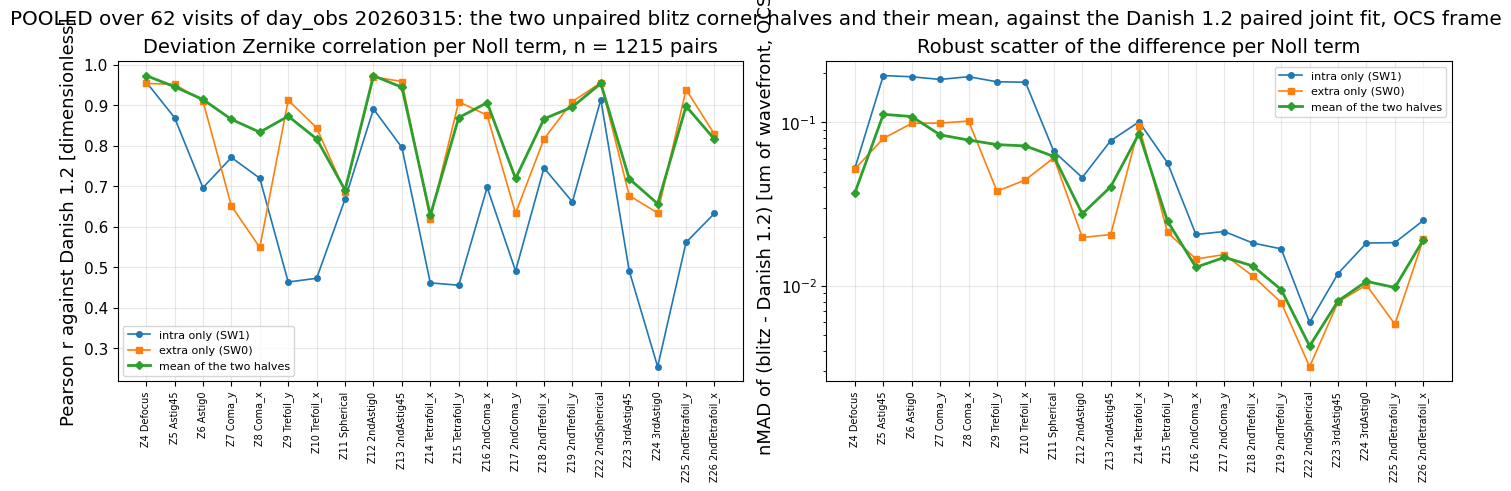

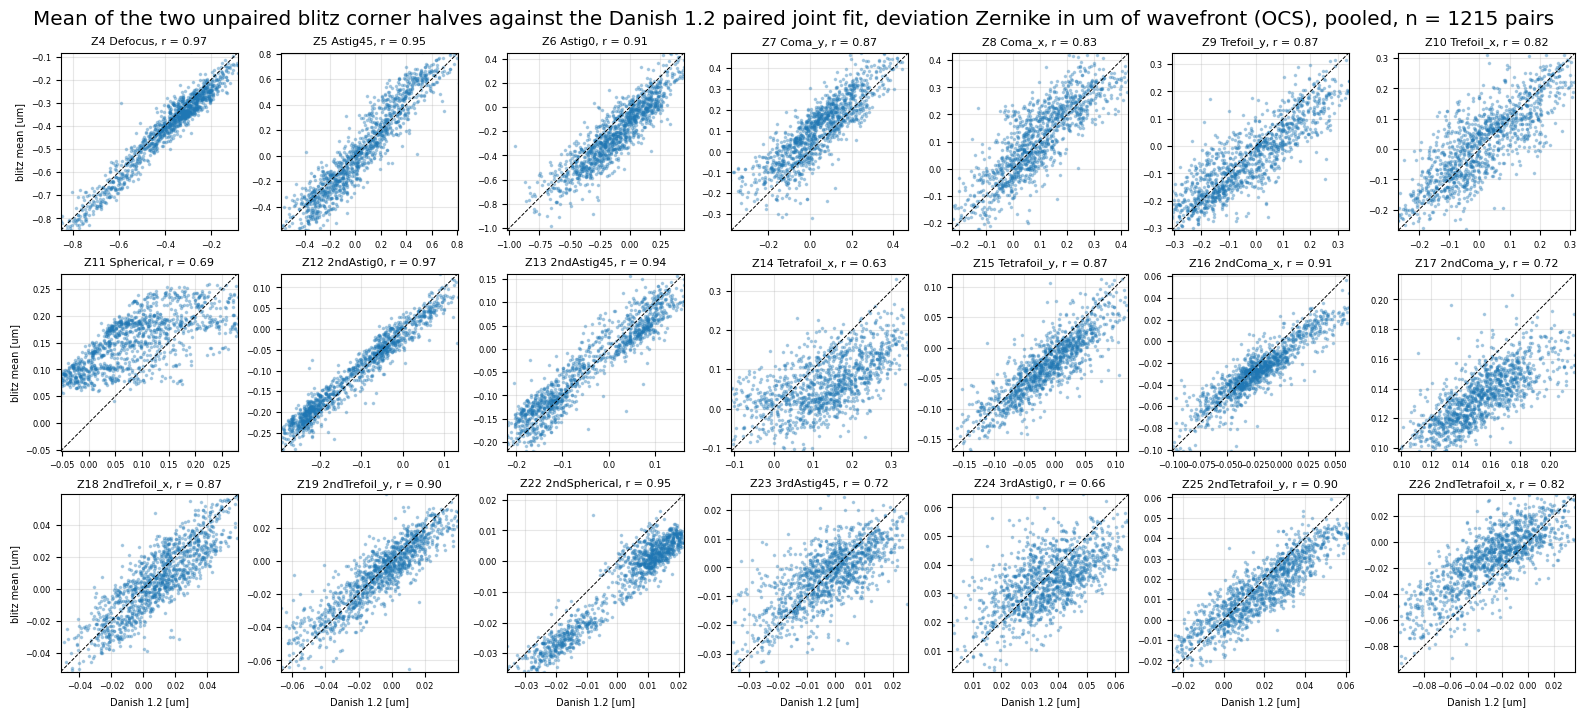

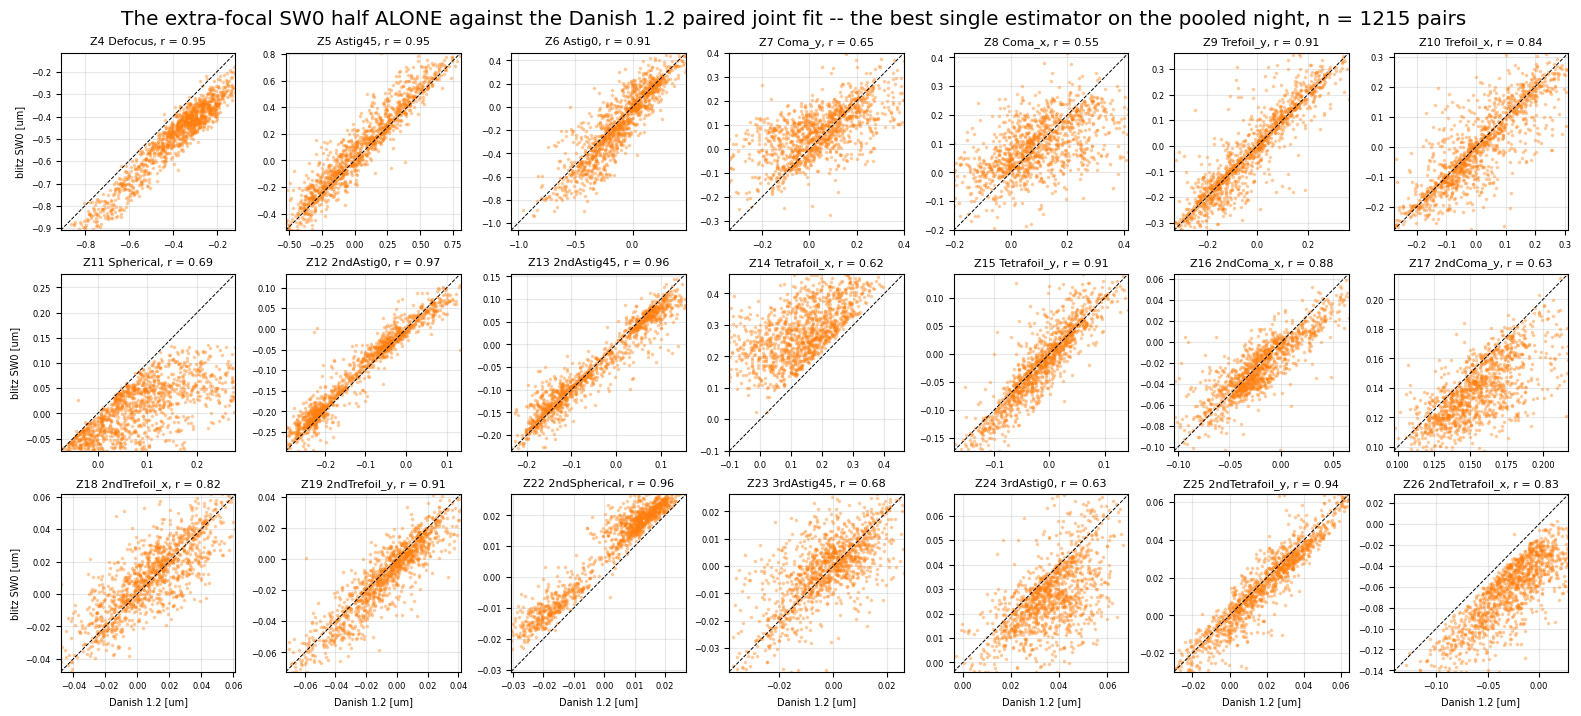

In [32]:
# The section 8.1 figures, redone on the pooled sample.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
xs = np.arange(len(NOLL))
for key, mk, lbl, lw in (('intra', 'o-', 'intra only (SW1)', 1.2),
                         ('extra', 's-', 'extra only (SW0)', 1.2),
                         ('mean', 'D-', 'mean of the two halves', 2.0)):
    axes[0].plot(xs, dev_pooled[f'r_{key}'], mk, ms=4, lw=lw, label=lbl)
    axes[1].plot(xs, dev_pooled[f'nmad_{key}'], mk, ms=4, lw=lw, label=lbl)
axes[0].set_ylabel('Pearson r against Danish 1.2 [dimensionless]')
axes[0].set_title(f'Deviation Zernike correlation per Noll term, n = {N_POOL} pairs')
axes[1].set_ylabel('nMAD of (blitz - Danish 1.2) [um of wavefront, OCS]')
axes[1].set_title('Robust scatter of the difference per Noll term')
axes[1].set_yscale('log')
for ax in axes:
    ax.set_xticks(xs)
    ax.set_xticklabels([zk_label(j) for j in NOLL], rotation=90, fontsize=7)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle(f'POOLED over {len(per_visit)} visits of day_obs {DAY_OBS}: the two unpaired '
             f'blitz corner halves and their mean, against the Danish 1.2 paired joint '
             f'fit, {COORD_OLD} frame')
plt.show()

# Per-Noll one-to-one scatter of the mean of the two halves against Danish 1.2, pooled.
ncol = 7
nrow = int(np.ceil(len(NOLL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.25 * ncol, 2.35 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    o = dev_old_p[:, c]
    m = dev_m_p[:, c]
    good = np.isfinite(o) & np.isfinite(m)
    # Pooled 1st-to-99th percentile RANGE over both axes, not a symmetric limit about
    # zero: several terms carry a real mean offset, so a symmetric frame would push the
    # cloud into a corner instead of filling the panel. This clips roughly 1 to 2 per
    # cent of the points, so these panels are NOT where outliers show up; every
    # statistic in the tables is computed on the unclipped arrays.
    lolim, hilim = np.nanpercentile(np.concatenate([o[good], m[good]]), [1.0, 99.0])
    ax.plot(o[good], m[good], 'o', ms=1.6, alpha=0.3)
    ax.plot([lolim, hilim], [lolim, hilim], 'k--', lw=0.7)
    ax.set_xlim(lolim, hilim)
    ax.set_ylim(lolim, hilim)
    ax.set_title(f'{zk_label(j)}, r = {dev_pooled["r_mean"].iloc[c]:.2f}', fontsize=8)
    ax.tick_params(labelsize=6)
    if c % ncol == 0:
        ax.set_ylabel('blitz mean [um]', fontsize=7)
    if c // ncol == nrow - 1:
        ax.set_xlabel('Danish 1.2 [um]', fontsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.axis('off')
fig.suptitle('Mean of the two unpaired blitz corner halves against the Danish 1.2 paired '
             f'joint fit, deviation Zernike in um of wavefront ({COORD_OLD}), pooled, '
             f'n = {N_POOL} pairs')
plt.show()

# And the better single estimator, the extra-focal SW0 half, on the same footing.
fig, axes = plt.subplots(nrow, ncol, figsize=(2.25 * ncol, 2.35 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    o = dev_old_p[:, c]
    m = dev_e_p[:, c]
    good = np.isfinite(o) & np.isfinite(m)
    lolim, hilim = np.nanpercentile(np.concatenate([o[good], m[good]]), [1.0, 99.0])
    ax.plot(o[good], m[good], 'o', ms=1.6, alpha=0.3, color='tab:orange')
    ax.plot([lolim, hilim], [lolim, hilim], 'k--', lw=0.7)
    ax.set_xlim(lolim, hilim)
    ax.set_ylim(lolim, hilim)
    ax.set_title(f'{zk_label(j)}, r = {dev_pooled["r_extra"].iloc[c]:.2f}', fontsize=8)
    ax.tick_params(labelsize=6)
    if c % ncol == 0:
        ax.set_ylabel('blitz SW0 [um]', fontsize=7)
    if c // ncol == nrow - 1:
        ax.set_xlabel('Danish 1.2 [um]', fontsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.axis('off')
fig.suptitle('The extra-focal SW0 half ALONE against the Danish 1.2 paired joint fit -- '
             f'the best single estimator on the pooled night, n = {N_POOL} pairs')
plt.show()

<a id='pervisit'></a>
### 10.2 Variation across visits

With 62 visits the statistics can themselves be given an error bar: the spread of the
per-visit Pearson r shows whether the pooled number describes a typical visit or an average
over very unlike ones. Each per-visit value below is computed on that visit's 12 to 25 pairs
alone, so it is individually noisy — the point is the distribution, not any single value.

per-visit statistics computed on 62 visits (a visit needs at least 3 pairs for a correlation)

Per-visit Pearson r against Danish 1.2, Z4 Defocus deviation Zernike [dimensionless]:
  intra only (SW1)        : median 0.7821, nMAD 0.1825, range 0.2890 to 0.9959, n = 62 visits
  extra only (SW0)        : median 0.7433, nMAD 0.1357, range 0.0706 to 0.9925, n = 62 visits
  mean of the two halves  : median 0.8616, nMAD 0.0852, range 0.3289 to 0.9976, n = 62 visits

Per-visit MEDIAN Pearson r over all 21 Noll terms [dimensionless]:
  intra only (SW1)        : median 0.6159, nMAD 0.0810, range 0.2393 to 0.8337, n = 62 visits
  extra only (SW0)        : median 0.7977, nMAD 0.0716, range 0.5859 to 0.9438, n = 62 visits
  mean of the two halves  : median 0.8319, nMAD 0.0447, range 0.6713 to 0.9100, n = 62 visits

Comparing the per-visit median Pearson r, visit by visit, n = 62 visits:
  the mean of both halves is higher on 40 visits, the extra (SW0) half on 22 visits
  the intra (SW1) half is the

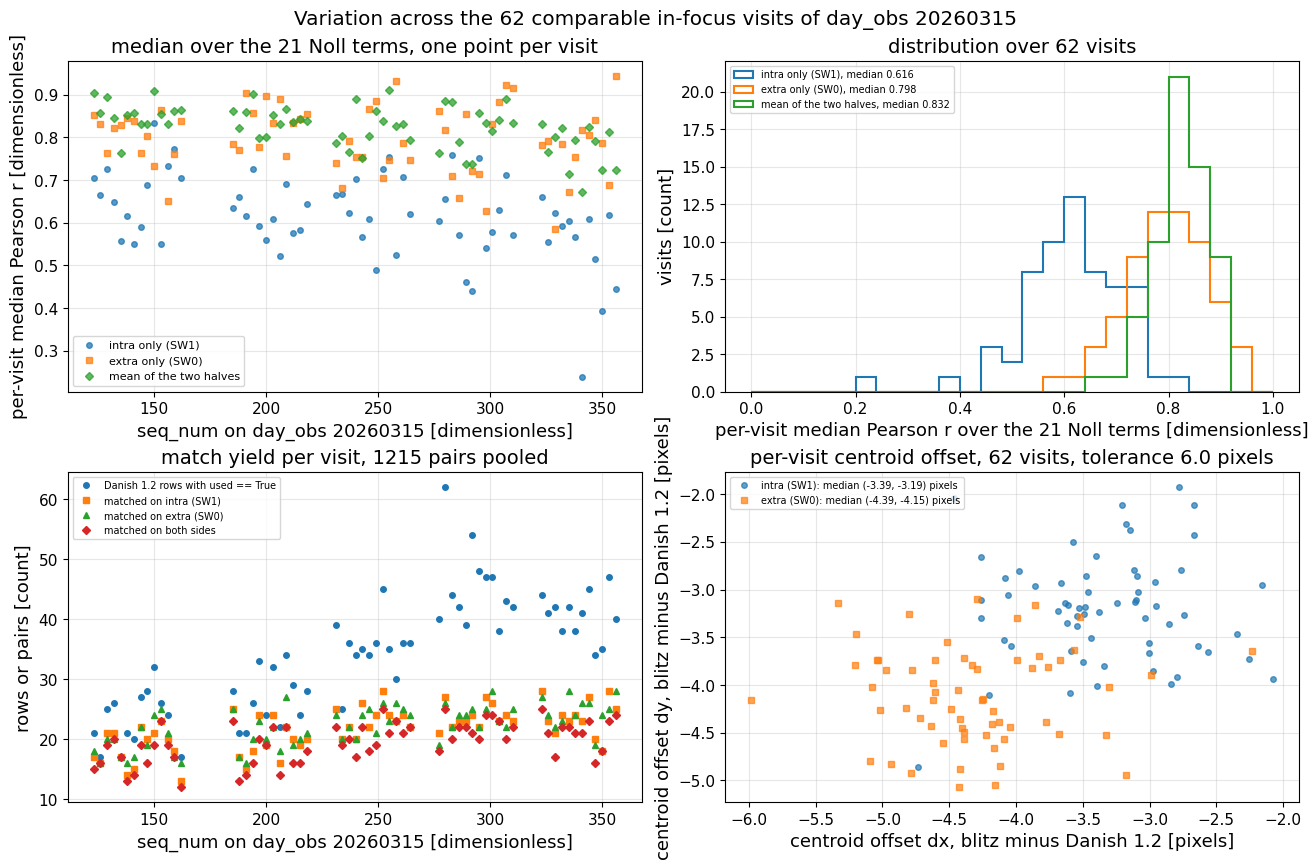

In [33]:
# Per-visit Pearson r on a representative low-order term and averaged over all 21,
# for each of the three cases. Each per-visit value uses only that visit's pairs.
J_SHOW = 4                                   # Noll 4 Defocus, the best-measured term
c_show = NOLL.index(J_SHOW)
rows = []
for v in per_visit['visit']:
    m = pool['visit'] == v
    if int(m.sum()) < 3:
        continue
    rec = dict(visit=int(v), seq_num=int(v % 100000), n_pairs=int(m.sum()))
    for tag, arr in (('intra', dev_i_p), ('extra', dev_e_p), ('mean', dev_m_p)):
        r, rho, n = corr_pair(dev_old_p[m, c_show], arr[m, c_show])
        rec[f'r_{tag}_z{J_SHOW}'] = r
        rec[f'rho_{tag}_z{J_SHOW}'] = rho
        # median over the 21 Noll terms, this visit only
        rr = [corr_pair(dev_old_p[m, c], arr[m, c])[0] for c in range(len(NOLL))]
        rec[f'r_{tag}_median'] = float(np.nanmedian(rr))
    rows.append(rec)
per_visit_r = pd.DataFrame(rows)
print(f'per-visit statistics computed on {len(per_visit_r)} visits '
      f'(a visit needs at least 3 pairs for a correlation)')

print(f'\nPer-visit Pearson r against Danish 1.2, {zk_label(J_SHOW)} deviation Zernike '
      '[dimensionless]:')
for tag, lbl in (('intra', 'intra only (SW1)'), ('extra', 'extra only (SW0)'),
                 ('mean', 'mean of the two halves')):
    v = per_visit_r[f'r_{tag}_z{J_SHOW}'].to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    print(f'  {lbl:24s}: median {np.median(v):.4f}, nMAD {nmad(v):.4f}, '
          f'range {v.min():.4f} to {v.max():.4f}, n = {len(v)} visits')

print('\nPer-visit MEDIAN Pearson r over all 21 Noll terms [dimensionless]:')
for tag, lbl in (('intra', 'intra only (SW1)'), ('extra', 'extra only (SW0)'),
                 ('mean', 'mean of the two halves')):
    v = per_visit_r[f'r_{tag}_median'].to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    print(f'  {lbl:24s}: median {np.median(v):.4f}, nMAD {nmad(v):.4f}, '
          f'range {v.min():.4f} to {v.max():.4f}, n = {len(v)} visits')
n_extra_better = int((per_visit_r['r_extra_median']
                      > per_visit_r['r_mean_median']).sum())
n_mean_better = int((per_visit_r['r_mean_median']
                     > per_visit_r['r_extra_median']).sum())
n_intra_worst = int((per_visit_r['r_intra_median']
                     < per_visit_r[['r_extra_median', 'r_mean_median']].min(axis=1)).sum())
print(f'\nComparing the per-visit median Pearson r, visit by visit, n = {len(per_visit_r)} '
      'visits:')
print(f'  the mean of both halves is higher on {n_mean_better} visits, '
      f'the extra (SW0) half on {n_extra_better} visits')
print(f'  the intra (SW1) half is the LOWEST of the three on {n_intra_worst} of '
      f'{len(per_visit_r)} visits')
print('So the SW1-is-worst result holds visit by visit and is not an artefact of pooling,')
print('while the mean-versus-SW0 ordering is close and metric-dependent -- see the next '
      'cell.')

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
# Per-visit median r against seq_num, all three cases.
for tag, mk, lbl in (('intra', 'o', 'intra only (SW1)'),
                     ('extra', 's', 'extra only (SW0)'),
                     ('mean', 'D', 'mean of the two halves')):
    axes[0, 0].plot(per_visit_r['seq_num'], per_visit_r[f'r_{tag}_median'], mk, ms=4,
                    alpha=0.75, label=lbl)
axes[0, 0].set_xlabel(f'seq_num on day_obs {DAY_OBS} [dimensionless]')
axes[0, 0].set_ylabel('per-visit median Pearson r [dimensionless]')
axes[0, 0].set_title('median over the 21 Noll terms, one point per visit')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

# Histogram of the same.
bins = np.linspace(0.0, 1.0, 26)
for tag, lbl in (('intra', 'intra only (SW1)'), ('extra', 'extra only (SW0)'),
                 ('mean', 'mean of the two halves')):
    v = per_visit_r[f'r_{tag}_median'].to_numpy(dtype=float)
    axes[0, 1].hist(v[np.isfinite(v)], bins=bins, histtype='step', lw=1.5,
                    label=f'{lbl}, median {np.nanmedian(v):.3f}')
axes[0, 1].set_xlabel('per-visit median Pearson r over the 21 Noll terms [dimensionless]')
axes[0, 1].set_ylabel('visits [count]')
axes[0, 1].set_title(f'distribution over {len(per_visit_r)} visits')
axes[0, 1].legend(fontsize=7)

# Pairs matched per visit.
axes[1, 0].plot(per_visit['seq_num'], per_visit['n_old_used'], 'o', ms=4,
                label='Danish 1.2 rows with used == True')
axes[1, 0].plot(per_visit['seq_num'], per_visit['n_intra'], 's', ms=4,
                label='matched on intra (SW1)')
axes[1, 0].plot(per_visit['seq_num'], per_visit['n_extra'], '^', ms=4,
                label='matched on extra (SW0)')
axes[1, 0].plot(per_visit['seq_num'], per_visit['n_both'], 'D', ms=4,
                label='matched on both sides')
axes[1, 0].set_xlabel(f'seq_num on day_obs {DAY_OBS} [dimensionless]')
axes[1, 0].set_ylabel('rows or pairs [count]')
axes[1, 0].set_title(f'match yield per visit, {N_POOL} pairs pooled')
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(alpha=0.3)

# Per-visit centroid offsets.
for s, mk, half in (('intra', 'o', 'SW1'), ('extra', 's', 'SW0')):
    axes[1, 1].plot(per_visit[f'dx_{s}'], per_visit[f'dy_{s}'], mk, ms=4, alpha=0.7,
                    label=f'{s} ({half}): median '
                          f'({per_visit[f"dx_{s}"].median():+.2f}, '
                          f'{per_visit[f"dy_{s}"].median():+.2f}) pixels')
axes[1, 1].set_xlabel('centroid offset dx, blitz minus Danish 1.2 [pixels]')
axes[1, 1].set_ylabel('centroid offset dy, blitz minus Danish 1.2 [pixels]')
axes[1, 1].set_title(f'per-visit centroid offset, {len(per_visit)} visits, '
                     f'tolerance {TOL_PIX} pixels')
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(alpha=0.3)
fig.suptitle(f'Variation across the {len(per_visit)} comparable in-focus visits of '
             f'day_obs {DAY_OBS}')
plt.show()

In [34]:
# The pooled nMAD and the per-visit Pearson r rank the three estimators DIFFERENTLY,
# which is worth pinning down rather than quoting whichever is convenient. Split the
# 21 Noll terms by which estimator wins, and check the low-order terms separately.
LOW = [4, 5, 6, 7, 8, 9, 10, 11]           # through Spherical
low = dev_pooled['noll'].isin(LOW).to_numpy()
print('Pooled nMAD of the difference, median over a subset of Noll terms '
      '[um of wavefront]:')
for lbl, m in (('all 21 fitted terms', np.ones(len(dev_pooled), dtype=bool)),
               ('the 8 low-order terms Z4 to Z11', low),
               ('the 13 higher-order terms Z12 to Z26', ~low)):
    print(f'  {lbl:38s}: intra {dev_pooled["nmad_intra"][m].median():.4f}, '
          f'extra {dev_pooled["nmad_extra"][m].median():.4f}, '
          f'mean {dev_pooled["nmad_mean"][m].median():.4f}')
print()
print('Pooled Pearson r, median over the same subsets [dimensionless]:')
for lbl, m in (('all 21 fitted terms', np.ones(len(dev_pooled), dtype=bool)),
               ('the 8 low-order terms Z4 to Z11', low),
               ('the 13 higher-order terms Z12 to Z26', ~low)):
    print(f'  {lbl:38s}: intra {dev_pooled["r_intra"][m].median():.4f}, '
          f'extra {dev_pooled["r_extra"][m].median():.4f}, '
          f'mean {dev_pooled["r_mean"][m].median():.4f}')

n_r = int((dev_pooled['r_mean'] > dev_pooled['r_extra']).sum())
n_n = int((dev_pooled['nmad_mean'] < dev_pooled['nmad_extra']).sum())
print(f'\nThe mean of both halves has the higher pooled Pearson r than the extra (SW0) '
      f'half alone on {n_r} of {len(dev_pooled)} Noll terms,')
print(f'but the smaller pooled nMAD of the difference on only {n_n} of '
      f'{len(dev_pooled)} terms.')
print('\nSo the two metrics genuinely disagree, and the disagreement is structured by '
      'Noll order:')
print(' - on CORRELATION the mean of both halves and the extra (SW0) half are close, '
      'and the')
print('   mean wins on more terms than it loses; the intra (SW1) half is clearly worst.')
print(' - on the SCATTER OF THE DIFFERENCE the extra half wins on the LOW-ORDER terms')
print('   (Z4 to Z11) while the mean of both wins on the HIGHER-ORDER terms (Z12 to '
      'Z26).')
print('   The low-order terms carry much the larger nMAD, so they dominate the median '
      'over')
print('   all 21 terms and make the extra half look uniformly better than it is.')
print('The two metrics are not the same question: Pearson r is insensitive to a scale')
print('error, nMAD is not. The honest summary is that NEITHER the mean of both halves nor')
print('the extra half alone is uniformly the better estimator at n = 1215 -- the ordering')
print('depends on the metric and on the Noll order, and the strong single-visit claim that')
print('the mean beats both halves is not supported.')

# Is the mean-vs-extra nMAD gap a scale effect? Compare the best-fit slope per term.
print('\nRobust slope of blitz against Danish 1.2 per Noll term (median of the ratio '
      'over pairs, dimensionless), median over the 21 terms:')
for tag, arr in (('intra (SW1)', dev_i_p), ('extra (SW0)', dev_e_p),
                 ('mean of both', dev_m_p)):
    sl = []
    for c in range(len(NOLL)):
        o, v = dev_old_p[:, c], arr[:, c]
        g = np.isfinite(o) & np.isfinite(v) & (np.abs(o) > 1e-3)
        sl.append(np.median(v[g] / o[g]) if int(g.sum()) > 10 else np.nan)
    print(f'  {tag:14s}: median slope {np.nanmedian(sl):.3f} (dimensionless), '
          f'nMAD over terms {nmad(np.asarray(sl)):.3f}')
print('A slope away from 1.000 (dimensionless) is a scale mismatch, not noise.')

Pooled nMAD of the difference, median over a subset of Noll terms [um of wavefront]:
  all 21 fitted terms                   : intra 0.0524, extra 0.0206, mean 0.0276
  the 8 low-order terms Z4 to Z11       : intra 0.1796, extra 0.0702, mean 0.0754
  the 13 higher-order terms Z12 to Z26  : intra 0.0206, extra 0.0146, mean 0.0133

Pooled Pearson r, median over the same subsets [dimensionless]:
  all 21 fitted terms                   : intra 0.6680, extra 0.8755, mean 0.8696
  the 8 low-order terms Z4 to Z11       : intra 0.7080, extra 0.8774, mean 0.8692
  the 13 higher-order terms Z12 to Z26  : intra 0.6330, extra 0.8755, mean 0.8696

The mean of both halves has the higher pooled Pearson r than the extra (SW0) half alone on 12 of 21 Noll terms,
but the smaller pooled nMAD of the difference on only 7 of 21 terms.

So the two metrics genuinely disagree, and the disagreement is structured by Noll order:
 - on CORRELATION the mean of both halves and the extra (SW0) half are close, and the


In [35]:
# Every number quoted in section 11 below, printed together so it can be checked
# against the prose without re-reading the notebook.
print('=== numbers quoted in the findings ===')
print(f'visits: blitz {len(visits_blitz)}, Danish 1.2 {len(visits_old)}, '
      f'comparable {len(visits_both)}, blitz-only {len(blitz_only)} '
      f'(seq_num {[v % 100000 for v in blitz_only]}), Danish-1.2-only {len(old_only)}')
print(f'failures: {len(failures)}')
print(f'used rows {tot_used}, matched intra {int(per_visit["n_intra"].sum())}, '
      f'extra {int(per_visit["n_extra"].sum())}, both {N_POOL} '
      f'({100.0 * N_POOL / tot_used:.0f} per cent of used, dimensionless)')
print(f'per-visit n_both: median {per_visit["n_both"].median():.0f}, '
      f'{int(per_visit["n_both"].min())} to {int(per_visit["n_both"].max())}')
print(f'match separation medians: intra {per_visit["sep_intra"].median():.2f} pixels, '
      f'extra {per_visit["sep_extra"].median():.2f} pixels')
print(f'intrinsic pooled: entries {d_mean_p.size}, mean-of-both median '
      f'{np.nanmedian(np.abs(d_mean_p)):.2e} um, max {np.nanmax(np.abs(d_mean_p)):.2e} um, '
      f'one half median {np.nanmedian(np.abs(int_i_p - int_old_p)):.2e} um, '
      f'|intrinsic| median {np.nanmedian(np.abs(int_old_p)):.4f} um, ratio to '
      f'half-separation {np.nanmedian(np.abs(d_mean_p)) / np.nanmedian(np.abs(d_half_p)):.1e}')
print('deviation pooled medians over 21 Noll [r, rho dimensionless; nMAD um of wavefront]:')
for tag in ('intra', 'extra', 'mean'):
    print(f'  {tag:6s}: r {dev_pooled[f"r_{tag}"].median():.4f}, '
          f'rho {dev_pooled[f"rho_{tag}"].median():.4f}, '
          f'nMAD {dev_pooled[f"nmad_{tag}"].median():.4f}')
print(f'  nMAD ratio mean/extra {dev_pooled["nmad_mean"].median() / dev_pooled["nmad_extra"].median():.2f}, '
      f'mean/intra {dev_pooled["nmad_mean"].median() / dev_pooled["nmad_intra"].median():.3f}, '
      f'intra/extra {dev_pooled["nmad_intra"].median() / dev_pooled["nmad_extra"].median():.1f}')
print('reference visit (n = %d) for contrast: r intra %.4f, extra %.4f, mean %.4f'
      % (len(common_old), dev_compare['r_intra'].median(),
         dev_compare['r_extra'].median(), dev_compare['r_mean'].median()))
print('per-visit median r: ' + ', '.join(
    f'{t} {per_visit_r[f"r_{t}_median"].median():.4f} +/- {nmad(per_visit_r[f"r_{t}_median"].to_numpy(float)):.4f}'
    for t in ('intra', 'extra', 'mean')))
print(f'extra beats mean on {n_extra_better} of {len(per_visit_r)} visits')
print('centroid offsets [pixels]: ' + '; '.join(
    f'{s} {a} median {per_visit[f"{a}_{s}"].median():+.2f} nMAD '
    f'{nmad(per_visit[f"{a}_{s}"].to_numpy(float)):.2f}'
    for s in ('intra', 'extra') for a in ('dx', 'dy')))

=== numbers quoted in the findings ===
visits: blitz 74, Danish 1.2 62, comparable 62, blitz-only 12 (seq_num [74, 77, 80, 83, 86, 89, 92, 95, 98, 101, 104, 107]), Danish-1.2-only 0
failures: 0
used rows 2095, matched intra 1346, extra 1377, both 1215 (58 per cent of used, dimensionless)
per-visit n_both: median 20, 12 to 25
match separation medians: intra 1.37 pixels, extra 1.67 pixels
intrinsic pooled: entries 25515, mean-of-both median 1.33e-06 um, max 4.17e-03 um, one half median 1.19e-03 um, |intrinsic| median 0.0105 um, ratio to half-separation 1.1e-03
deviation pooled medians over 21 Noll [r, rho dimensionless; nMAD um of wavefront]:
  intra : r 0.6680, rho 0.6918, nMAD 0.0524
  extra : r 0.8755, rho 0.8545, nMAD 0.0206
  mean  : r 0.8696, rho 0.8698, nMAD 0.0276
  nMAD ratio mean/extra 1.34, mean/intra 0.526, intra/extra 2.5
reference visit (n = 15) for contrast: r intra 0.7052, extra 0.8516, mean 0.9035
per-visit median r: intra 0.6159 +/- 0.0810, extra 0.7977 +/- 0.0716, mean

<a id='findings'></a>
## 11. Findings for Josh

Every number below comes from the executed cells above, for `day_obs = 20260315`. The
format-level findings (sections 5 to 9) were established on the reference visit
`2026031500123`; the value comparisons are on the **pooled sample of 1215 Danish 1.2 pairs
over all 62 comparable in-focus visits** of the night, and each carries its n.

### Coverage and yield

All **62** comparable in-focus visits read and matched with **zero failures** — no visit
raised, and none came back degenerate. The two collections do not cover the same visits,
though: `donutBlitzResults` has **74** visits on this night and `aggregateAOSVisitTableRaw`
has **62**, with 62 in both, **12 blitz-only** (seq_num 74, 77, 80, 83, 86, 89, 92, 95, 98,
101, 104, 107) and **zero** Danish-1.2-only. So the blitz reduction covers an early block of
the night that Danish 1.2 does not, and that block cannot be compared at all.

Of **2095** Danish 1.2 rows with `used == True` summed over the 62 visits, **1346** matched
on the intra-focal (`SW1`) side, **1377** on the extra-focal (`SW0`) side, and **1215** on
**both** — the pooled sample. That is 58 per cent of the used rows (dimensionless; 64.2 per cent matched on the intra
side and 65.7 per cent on the extra side), 12 to 25
pairs per visit with a median of 20. The yield is even across the night; no visit matched
anomalously badly. The loss is dominated by the blitz `group_fit_success` cut and by donuts
that one product kept and the other did not, not by the positional match, whose median
separation after the offset is removed is 1.37 pixels on the intra side and 1.67 pixels
on the extra side, against a 6.0-pixel tolerance.

### The intrinsic wavefront is an exact convention check, and it passes on the whole night

The strongest result here, and the one that does not depend on the sample size. Over all 1215
pairs and 21 Noll terms — 25 515 entries — the **mean of the two blitz halves' intrinsic
Zernikes** reproduces the Danish 1.2 per-pair intrinsic to a median **1.33e-06 µm of
wavefront** and a **maximum 4.17e-03 µm of wavefront**, against a median |intrinsic| of
**0.0105 µm of wavefront**. Either half **alone** differs by a median **1.19e-03 µm of
wavefront**, which is the field-position gradient across the separation between the two
donuts of a pair, so the mean-of-both residual is about **1.1e-03 (dimensionless)** of that
separation.

So the Danish 1.2 per-pair intrinsic **is** the arithmetic mean of the two donuts' own
field-position evaluations. The units, the Noll indexing and the OCS frame therefore match
exactly between the two reductions, with no scaling and no rotation. On the reference visit
alone this held to a median 1.33e-06 µm of wavefront; it holds to the same median across 62
visits, which turns a one-visit coincidence into a convention test.

### The fitted deviation: SW1 is clearly the worst half, and the mean-versus-SW0 ordering depends on the metric

**This withdraws what the reference visit alone suggested, and it is the main reason the
extension was worth doing.** Median over the 21 fitted Noll terms, n = **1215** pairs:

| quantity, median over the 21 fitted Noll | intra only (SW1) | extra only (SW0) | mean of both halves |
|---|---|---|---|
| Pearson r against Danish 1.2 [dimensionless] | 0.6680 | **0.8755** | 0.8696 |
| Spearman rho against Danish 1.2 [dimensionless] | 0.6918 | 0.8545 | **0.8698** |
| nMAD of (blitz − Danish 1.2) [µm of wavefront] | 0.0524 | **0.0206** | 0.0276 |

The one unambiguous result is that the **intra-focal `SW1` half alone is the worst estimator
of the three**, on every metric and on essentially every term: its nMAD is a factor **2.5
(dimensionless, nMAD of SW1 over nMAD of SW0)** larger than the extra-focal half's.

The extra half and the mean of both, however, are **not cleanly ordered**, and saying which
is better depends on the metric:

- On **correlation** the mean of both wins more often — the higher pooled Pearson r on
  **12 of 21** Noll terms, and the higher per-visit median r (0.8319 with nMAD 0.0447 against
  0.7977 with nMAD 0.0716, n = 62 visits), with the mean also ahead on 40 of the 62
  individual visits.
- On the **nMAD of the difference** the extra half wins on **14 of 21** terms, and the ratio
  of the median nMAD, mean-of-both over extra alone, is **1.34 (dimensionless)** — averaging
  in the intra half makes the absolute agreement worse. Over intra alone that ratio is
  **0.526 (dimensionless)**, below the 0.707 an independent-noise average of two equally good
  estimates would give, but that only says the mean beats the worse of its two inputs.

The split is **structured by Noll order**: the extra half has the smaller nMAD on the
low-order terms Z4 to Z11 (median 0.0702 against 0.0754 µm of wavefront) and the mean of
both has the smaller nMAD on the higher-order terms Z12 to Z26 (median 0.0133 against
0.0146 µm of wavefront). The low-order terms carry much the larger scatter, so they set the
median over all 21 terms and make the extra half look more uniformly better than it is.

Pearson r is insensitive to a scale error and nMAD is not, which is consistent with a scale
mismatch rather than pure noise: the median robust slope of blitz against Danish 1.2 over the
21 terms is **0.836 (dimensionless)** for the intra half, **0.941** for the extra half and
**0.874** for the mean, none of them 1.000.

On the reference visit alone (n = 15 pairs) the mean appeared to beat both halves cleanly, at
Pearson r 0.9035 against 0.8516 and 0.7052. At n = 1215 that clean ordering is gone. **The
honest statement is that neither the mean of both halves nor the SW0 half alone is uniformly
the better estimator**, and a reader who wants one number from an unpaired corner reduction
has to choose according to which Noll orders and which metric matter for the application.

**The asymmetry between the two halves is the finding, and it is not explained here.**
Candidate explanations this notebook does **not** distinguish between: an intra-focal
pupil-mask or vignetting difference on the `SW1` half, a sign or offset convention applied to
only one half, or a genuine difference in how well an unpaired intra-focal corner donut
constrains the wavefront. The non-unit slopes above say at least part of it is a scale
effect, which would point at the first two rather than the third, but that is suggestive and
not established.

### Variation across visits, which the single visit could not show

Per-visit median Pearson r over the 21 Noll terms — one value per visit, each from that
visit's 12 to 25 pairs, so individually noisy (n = 62 visits): **intra only (SW1)** median
0.6159 with nMAD 0.0810, range 0.2393 to 0.8337; **extra only (SW0)** median 0.7977 with
nMAD 0.0716, range 0.5859 to 0.9438; **mean of both halves** median 0.8319 with nMAD 0.0447,
range 0.6713 to 0.9100. The `SW1`-is-worst result holds visit by visit: the intra half has
the lowest of the three per-visit median r values on **54 of the 62** visits, so it is not an
artefact of pooling. The per-visit spread is small enough that the pooled numbers describe a
typical visit rather than an average over unlike ones.

Note that the per-visit statistic ranks the **mean of both halves first** — higher on 40 of
the 62 visits against 22 for the extra half — while the pooled nMAD ranks the extra half
first. Both are reported above rather than picking one; the
disagreement is the same metric-dependence discussed above, not an inconsistency.

### Pixel coordinates: a stable convention offset across the whole night

Both products report **unbinned** detector pixels despite blitz `binning` = 2 (dimensionless,
pixels per bin per axis) and the `bin_x2` Danish 1.2 collection. The constant offset is
present on every visit and is **stable across the night**, measured independently each time:
median **dx = −3.39, dy = −3.19 pixels** with nMAD 0.54 and 0.50 pixels on the intra side,
and median **dx = −4.39, dy = −4.15 pixels** with nMAD 0.54 and 0.54 pixels on the extra
side, over 62 visits. The full range is about 2 to 6 pixels on each axis, comfortably inside
the 6.0-pixel tolerance. So this is a fixed pixel-origin convention difference, not a
per-visit astrometric wander — and worth pinning down explicitly, since every reader
otherwise has to rediscover it. Note the offset differs between the two sides of focus by
about 1 pixel, which a single shared constant would not capture.

### The corner geometry makes this a different comparison from FAM

Each corner raft carries two half-sensors, `SW0` 1.5 mm beyond focus and `SW1` 1.5 mm inside
focus, and they are **different CCDs pointed at different stars**. On the reference visit the
blitz `donut_id` (a Gaia-like source id) sets on the two halves share **0 of 68 sources**, so
there is no such thing as the same star on both sides of focus — unlike FAM, where the two
exposures give two looks at one star. Danish 1.2 still emits one row per **pair**, pairing a
star on `SW0` with a different star on `SW1`.

Consequences a reader has to respect:

1. **`donut_id` cannot pair the two halves**, and neither can sky position. The only join is
   detector plus pixel position, one half at a time.
2. **"The mean of the two sides" means the mean over two different stars**, not a repeat
   measurement — which is part of why averaging does not behave like a noise average here.
3. **The intrinsic is evaluated per donut**, and Danish 1.2 reports the mean of the pair, as
   established above.

### The Danish 1.2 `detector` column is a trap on the corner product

`detector` reads the **extra-focal** half-sensor — `R00_SW0`, `R04_SW0`, `R40_SW0`,
`R44_SW0` — for **both** members of every pair: on the reference visit it agrees with the
parsed extra-focal detector on 21 of 21 used rows and with the parsed intra-focal detector on
0 of 21. The intra-focal half is recoverable **only** from the detector id embedded in the
`intra_donut_id` string, which has the form `{visit_id}_{det_id}_{seq}`, e.g.
`2026031500123_192_001` with det_id 192 = `R00_SW1` against det_id 191 = `R00_SW0`. Any
reader that takes `detector` as the detector of both donuts silently attributes the
intra-focal donut to the wrong CCD. Naming both halves explicitly, or adding
`detector_intra` / `detector_extra`, would remove the trap. This is a **Danish 1.2** problem,
not a blitz one — the blitz carries `det_id` and `det_name` per row and is unambiguous.

### The two products' reads are asymmetric, and both asymmetries bite

- The blitz table needs `parameters={'strip_astropy_meta_yaml': False}` or `.meta` comes back
  with **0 keys** instead of **359**. Same request as in the FAM notebook: make it the default
  or document it.
- Passing that **same** parameter to the Danish 1.2 `aggregateAOSVisitTableRaw` raises
  `KeyError: "Parameter 'strip_astropy_meta_yaml' not understood by StorageClass
  AstropyTable"`. So a helper that reads both products cannot simply pass the parameter
  through; it has to know which dataset type it is holding. This bites directly in the
  62-visit loop, where both reads sit side by side.

### Metadata and provenance

The blitz corner metadata splits as **39 science/config keys + a `det_meta` dict with 8
detector-exposure entries + the `LSST.BUTLER.*` input provenance**, and the science keys are
identical to the FAM product's. It states `noll_indices`, the three boresight angles with
**astropy units attached**, `binning`, `stamp_frame`, `stamp_size`, `mode`, `wf_mode`, the
`ts_wep` / `danish` / `batoid` versions, and — through the provenance — that the intrinsic
wavefront came from `intrinsicZernikes` in
`LSSTCam/calib/DM-55048/intrinsicZernikes.v1.0/intrinsicsGen.20260528a`. Unlike the FAM
product, `ptc`, `flat` and `linearizer` each come from a **single** run collection here, so
the two-collection split the FAM notebook flagged does not appear on the corner.

The Danish 1.2 corner table carries **12 metadata keys** and **no provenance block**, and its
angles are **bare floats in radians with no unit** against the blitz astropy Quantity in deg.
Converted, the two agree on the three angles to the precision printed in section 5. The blitz
behaviour is the right one.

### `defocal_offsets` element order: the corner product confirms the FAM request

The corner product varies **element 0** of the `defocal_offsets` 3-vector
(`[±0.0015, 0, 0]` m) while the FAM product varies **element 1** (`[0, ±0.0015, 0]` m). The
element order is stated nowhere in the table or its metadata, so a reader that hardcodes an
index mislabels the side of focus in one of the two products — and on the corner product that
also mislabels the half-sensor, which given the `SW0`/`SW1` asymmetry found above would
silently pick the worse of the two halves. Same request as the FAM notebook, now with a second
independent instance and a concrete consequence.

### No donut-width comparison is possible on this product

The Danish 1.2 corner `aggregateAOSVisitTableRaw` has **no `blur` column**, and no other
column whose name contains `blur` or `fwhm`. The FAM notebook had one only because it read
the table through `intrinsics_lib.get_aggregate_zernikes`, which derives `blur` from the
per-donut `estimatorInfo` diagnostics carried in the metadata. Rather than invent a
counterpart, section 9 reports the blitz `group_fwhm` distribution on its own and the `snr`
columns that both products do carry. The blitz `group_fwhm` does arrive with its unit attached
(arcsec), which is the right behaviour.

As in FAM, the blitz `snr` and the Danish 1.2 `snr` are **not the same quantity** — a ratio of
medians of about 5 to 6 (dimensionless, Danish 1.2 over blitz) on the reference visit — so the
columns are not interchangeable despite the shared name. The rank correlation is excellent
(Spearman rho above 0.94), which is what confirms the match, but a note on the definition or a
distinct column name would prevent a silent misuse.

### Open question, explicitly not claimed as understood

Any Z11 Spherical or Z14 Tetrafoil_x split between the intra- and extra-focal halves in the
tables above is reported as **unexplained**. An intra- versus extra-focal split on exactly
those two terms in the unpaired Danish corner output is a known **open question** in this
repository, with no established instrumental cause, and the FAM counterpart notebook saw the
same structure. The pooled sample here makes the split better measured but no better
understood, and nothing in this notebook explains it. The broader `SW0`-versus-`SW1`
asymmetry reported above may or may not be the same effect; this notebook does not establish
that either way.